# EKF Robot Localization

Extended Kalman Filter for mobile robot localization, fusing **BNO055 IMU** and **Lidar** sensor data.

A robot navigates a 10×10m square path in an open field, with a single pylon landmark at (5.0, −5.0). The EKF fuses IMU-based motion prediction with Lidar-derived position corrections to estimate the robot's pose.

Two correction strategies are compared:
- **Every step** (10 Hz corrections): mean tracking error 0.181 m
- **Every other step** (5 Hz corrections): mean tracking error 0.176 m — nearly identical accuracy, but 135% higher position uncertainty

## Setup
1. Upload the data folder to Google Drive
2. Open this notebook in Google Colab
3. Mount Drive when prompted
4. Update `DATA_FILE` in Section 7 to point to your CSV
5. Run cells top to bottom

## Dependencies
```
numpy, pandas, matplotlib
```
*(All pre-installed in Google Colab)*

**Goal:** Use Lidar/IMU data from a robot navigating a 10×10m square path. A pylon at (5, −5) serves as the sole landmark. The EKF localizes the robot using:
- **Prediction step:** IMU forward acceleration + yaw rate
- **Correction step:** Lidar landmark measurements transformed to global-frame position

**Coordinate conventions:**
- Global frame: East = +x, North = +y, yaw CCW positive
- IMU frame: yaw CW positive → must negate before use
- Lidar frame: forward = y-axis, right = x-axis

**State vector (5×1):** `[x, y, vx, vy, θ]ᵀ`

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import warnings
warnings.filterwarnings("ignore")

In [3]:
x_landmark = 5 # meters East
y_landmark = -5 #meters North so actually to the South

Assuming data is logged at 10Hz as the time stamps seem corrupted

In [4]:
dT = 0.1 # seconds (1/10Hz)

Ensure all angles are in radians and convert any degrees to radians

In [5]:
state_dim = 5

In [6]:
earth_rad = 6.3781E6 # meters, for GPS conversion

In [7]:
# EKF Tuning Parameters - adjust these based on your data characteristics
PROCESS_NOISE_STD = {
    'x': 0.1,       # Position uncertainty (m)
    'y': 0.1,       # Position uncertainty (m)
    'vx': 0.5,      # Velocity uncertainty (m/s)
    'vy': 0.5,      # Velocity uncertainty (m/s)
    'theta': 0.1    # Angle uncertainty (rad)
}

MEASUREMENT_NOISE_STD = {
    'x': 0.3,       # Lidar-derived x position noise (m)
    'y': 0.3,       # Lidar-derived y position noise (m)
    'theta': 0.05   # IMU yaw noise (rad)
}

In [12]:

# =============================================================================
# SECTION 2: UTILITY FUNCTIONS
# =============================================================================

def wrap_to_pi(angle):
    """
    Wrap angle to [-pi, pi] range

    use angle wrap function every time you take the difference of two angles

    Parameters:
    -----------
    angle : float or np.array
        Angle(s) in radians to wrap

    Returns:
    --------
    float or np.array : Wrapped angle(s) in [-pi, pi]
    """
    return (angle + np.pi) % (2 * np.pi) - np.pi


def moving_average_filter(data, window_size=9):
    """
    Apply moving average filter to data

    Parameters:
    -----------
    data : array-like
        Data to filter
    window_size : int
        Size of moving window (default: 9)

    Returns:
    --------
    np.array : Filtered data
    """
    data = np.asarray(data, dtype=float)
    filtered = np.empty_like(data)

    for i in range(len(data)):
        start_idx = max(0, i - window_size + 1)
        filtered[i] = np.mean(data[start_idx:i+1])

    return filtered


def convert_gps_to_xy(lat, lon, lat_origin, lon_origin):
    """
    Convert GPS coordinates to Cartesian using equirectangular projection

    Used for GPS comparison plots

    Parameters:
    -----------
    lat, lon : float or array
        GPS coordinates to convert
    lat_origin, lon_origin : float
        Origin GPS coordinates

    Returns:
    --------
    tuple : (x, y) in meters
    """
    x = earth_rad * (np.pi/180.0) * (lon - lon_origin) * np.cos((np.pi/180.0) * lat_origin)
    y = earth_rad * (np.pi/180.0) * (lat - lat_origin)
    return x, y

In [14]:

# =============================================================================
# SECTION 3: DATA LOADING AND PREPROCESSING
# =============================================================================

def load_and_preprocess_data(filepath):
    """
    Load CSV data and preprocess for EKF

    This function handles all coordinate transformations and data filtering
    as specified in the lab instructions.

    Parameters:
    -----------
    filepath : str
        Path to the filtered CSV file

    Returns:
    --------
    dict : Preprocessed data ready for EKF
    """

    # Load CSV (no header in filtered files)
    print(f"\nLoading: {filepath}")
    df = pd.read_csv(filepath, header=None)

    # 13-column CSV (sometimes has extra empty column)
    if df.shape[1] == 13:
        if df.iloc[:, 12].isna().mean() > 0.95:
            df = df.iloc[:, :12]
        else:
            df = df.iloc[:, 1:13]

    print(f"Data shape: {df.shape}")

    # Convert to numeric array
    data_matrix = df.apply(pd.to_numeric, errors='coerce').to_numpy()
    n_points = data_matrix.shape[0]

    # =========================================================================
    # COLUMN ASSIGNMENTS (filtered CSV format)
    # =========================================================================
    #
    # Column order in filtered CSV:
    # Col 0:  Lidar X (meters) - "x-axis is to the right" in robot frame
    # Col 1:  Lidar Y (meters) - "y-axis is forward" in robot frame
    # Col 2:  Lidar Z (meters) - height
    # Col 3:  Timestamp (nanoseconds) - "time stamps seem corrupted"
    # Col 4:  Latitude (degrees)
    # Col 5:  Longitude (degrees)
    # Col 6:  Yaw (degrees) - needs conversion
    # Col 7:  Pitch (degrees)
    # Col 8:  Roll (degrees)
    # Col 9:  AccelX (m/s²) - "x-axis is forward" in robot frame
    # Col 10: AccelY (m/s²) - "y-axis is to the left" in robot frame
    # Col 11: AccelZ (m/s²)
    # =========================================================================


    # Extract raw data from correct columns
    lidar_x_raw = data_matrix[:, 0]  # Right in robot frame
    lidar_y_raw = data_matrix[:, 1]  # Forward in robot frame
    lidar_z_raw = data_matrix[:, 2]  # Up/down
    lat = data_matrix[:, 4]          # Latitude
    lon = data_matrix[:, 5]          # Longitude
    yaw_raw = data_matrix[:, 6]      # Yaw angle
    accel_x_raw = data_matrix[:, 9]  # Forward acceleration
    accel_y_raw = data_matrix[:, 10] # Lateral acceleration (left)


    # =========================================================================
    # YAW ANGLE PROCESSING
    # =========================================================================
    # The positive yaw angle direction is CCW [in global frame]
    # The positive IMU yaw angle direction is CW
    # This means you must transform the yaw measurements before using them
    # Ensure that all angles are in radians (and convert any degrees to radians

    # Check if yaw is in degrees or radians
    yaw_max = np.nanmax(yaw_raw)
    yaw_is_degrees = (yaw_max > 50)  # If max > 50, likely degrees (0-360)

    if yaw_is_degrees:
        print(f"Yaw is in DEGREES (max = {yaw_max:.1f}°)")
        print("  Converting to radians...")
        yaw_rad = np.deg2rad(yaw_raw)
    else:
        print(f"Yaw is already in RADIANS (max = {yaw_max:.3f} rad)")
        yaw_rad = yaw_raw

    # Convert from CW to CCW convention
    # IMU: CW positive (clockwise from East)
    # Global frame needed: CCW positive (counter-clockwise from East)
    # Transformation: theta_global = -theta_IMU
    print("  Flipping sign (CW → CCW)...")
    theta_ccw = wrap_to_pi(-yaw_rad)

    print(f"  Final yaw range: [{np.nanmin(theta_ccw):.3f}, {np.nanmax(theta_ccw):.3f}] rad")
    print(f"  Final yaw range: [{np.rad2deg(np.nanmin(theta_ccw)):.1f}, {np.rad2deg(np.nanmax(theta_ccw)):.1f}]°")

    # =========================================================================
    # ACCELERATION FILTERING
    # =========================================================================
    # Filter the IMU acceleration data

    # Apply moving average filter with window size 9
    accel_x_filtered = moving_average_filter(accel_x_raw, window_size=9)
    accel_y_filtered = moving_average_filter(accel_y_raw, window_size=9)

    print(f" Applied moving average filter (window size = 9)")
    print(f"  Accel X range: [{np.nanmin(accel_x_filtered):.3f}, {np.nanmax(accel_x_filtered):.3f}] m/s²")
    print(f"  Accel Y range: [{np.nanmin(accel_y_filtered):.3f}, {np.nanmax(accel_y_filtered):.3f}] m/s²")

    # =========================================================================
    # YAW VELOCITY COMPUTATION
    # =========================================================================
    # Preprocess the yaw data to create the yaw velocity,
    # which can be used as an input into the system"


    yaw_velocity = np.zeros(n_points)
    for i in range(1, n_points):
        # Hint 2: Use wrap_to_pi when taking difference of angles!
        yaw_diff = wrap_to_pi(theta_ccw[i] - theta_ccw[i-1])
        yaw_velocity[i] = yaw_diff / dT

    print(f"✓ Computed yaw velocity (omega)")
    print(f"  Range: [{np.nanmin(yaw_velocity):.3f}, {np.nanmax(yaw_velocity):.3f}] rad/s")

    # =========================================================================
    # REMOVE INVALID DATA POINTS
    # =========================================================================

    print("\n" + "-"*80)
    print("DATA VALIDATION")
    print("-"*80)

    valid_mask = (np.isfinite(lidar_x_raw) &
                  np.isfinite(lidar_y_raw) &
                  np.isfinite(theta_ccw) &
                  np.isfinite(accel_x_filtered) &
                  np.isfinite(accel_y_filtered))

    n_valid = np.sum(valid_mask)
    print(f"✓ Valid data points: {n_valid} / {n_points} ({100*n_valid/n_points:.1f}%)")

    # Apply mask to all data
    lidar_x = lidar_x_raw[valid_mask]
    lidar_y = lidar_y_raw[valid_mask]
    theta = theta_ccw[valid_mask]
    accel_x = accel_x_filtered[valid_mask]
    accel_y = accel_y_filtered[valid_mask]
    omega = yaw_velocity[valid_mask]

    # =========================================================================
    # COMPUTE MEASUREMENTS z_t
    # =========================================================================
    # Transform all lidar position measurements into
    # direct measurements of the robot's x, y, yaw states
    #
    # Equations from Hint 5:
    #   zx,t = 5 - [ylidar*cos(θt) + xlidar*sin(θt)]
    #   zy,t = -5 - [ylidar*sin(θt) - xlidar*cos(θt)]
    #   zθ,t = θlidar,t

    print("\n" + "-"*80)
    print("COMPUTING MEASUREMENTS z_t")
    print("-"*80)
    print("\nApplying Hint 5 transformation:")
    print(f"  z_x = {x_landmark} - [y_lidar*cos(θ) + x_lidar*sin(θ)]")
    print(f"  z_y = {y_landmark} - [y_lidar*sin(θ) - x_lidar*cos(θ)]")
    print(f"  z_θ = θ")

    z_x = x_landmark - (lidar_y * np.cos(theta) + lidar_x * np.sin(theta))
    z_y = y_landmark - (lidar_y * np.sin(theta) - lidar_x * np.cos(theta))
    z_theta = theta

    print(f"\n✓ Measurements computed:")
    print(f"  z_x range: [{np.min(z_x):.3f}, {np.max(z_x):.3f}] m")
    print(f"  z_y range: [{np.min(z_y):.3f}, {np.max(z_y):.3f}] m")
    print(f"  Width:  {np.max(z_x) - np.min(z_x):.2f} m (should be ~10 m)")
    print(f"  Height: {np.max(z_y) - np.min(z_y):.2f} m (should be ~10 m)")

    # =========================================================================
    # VALIDATE MEASUREMENTS
    # =========================================================================

    x_width = np.max(z_x) - np.min(z_x)
    y_height = np.max(z_y) - np.min(z_y)

    if x_width > 7 and y_height > 7:
        print("\n VALIDATION PASSED: Measurements form a box shape!")
    else:
        print("\n  WARNING: Measurements may not form a proper box!")
        print(f"   X width: {x_width:.2f}m, Y height: {y_height:.2f}m")

    # =========================================================================
    # EXTRACT GPS DATA (for comparison plots)
    # =========================================================================

    print("\n" + "-"*80)
    print("GPS DATA EXTRACTION")
    print("-"*80)

    lat_raw = data_matrix[:, 4]
    lon_raw = data_matrix[:, 5]

    if np.sum(np.isfinite(lat_raw)) > 0:
        lat = lat_raw[valid_mask]
        lon = lon_raw[valid_mask]

        # Convert to local XY
        lat_origin = lat[np.isfinite(lat)][0]
        lon_origin = lon[np.isfinite(lon)][0]
        gps_x, gps_y = convert_gps_to_xy(lat, lon, lat_origin, lon_origin)

        print(f"✓ GPS data extracted and converted to local XY")
        has_gps = True
    else:
        print(" No valid GPS data found")
        gps_x = None
        gps_y = None
        has_gps = False

    # =========================================================================
    # PACKAGE DATA FOR RETURN
    # =========================================================================

    data_dict = {
        # Processed measurements for EKF
        'z_x': z_x,                    # Position measurements (transformed)
        'z_y': z_y,
        'z_theta': z_theta,

        # Raw sensor data
        'lidar_x': lidar_x,            # Lidar in robot frame
        'lidar_y': lidar_y,
        'theta': theta,                # Yaw angle (CCW positive)
        'accel_x': accel_x,            # Filtered accelerations
        'accel_y': accel_y,
        'omega': omega,                # Yaw velocity

        # GPS data (if available)
        'gps_x': gps_x,
        'gps_y': gps_y,
        'has_gps': has_gps,

        # Metadata
        'n_points': len(z_x),
        'dt': dT,
        'time': np.arange(len(z_x)) * dT
    }

    print("\n" + "="*80)
    print("DATA PREPROCESSING COMPLETE")
    print("="*80)
    print(f"✓ {len(z_x)} valid data points ready for EKF")

    return data_dict





✓ EKF class defined
✓ Visualization functions defined
✓ Main EKF function defined

READY TO RUN LAB 3 EKF!

To execute the lab:
1. Set the path to your filtered CSV file below
2. Run the cells in order
3. Results will be generated for both correction modes

 Data file: /content/drive/MyDrive/E205/E205LABS/E205Lab3/2020_2_26__17_21_59_filtered.csv

  If the path above is incorrect, update the DATA_FILE variable and re-run

Loading: /content/drive/MyDrive/E205/E205LABS/E205Lab3/2020_2_26__17_21_59_filtered.csv
Data shape: (707, 12)
Yaw is in DEGREES (max = 359.9°)
  Converting to radians...
  Flipping sign (CW → CCW)...
  Final yaw range: [-3.142, 3.138] rad
  Final yaw range: [-180.0, 179.8]°
 Applied moving average filter (window size = 9)
  Accel X range: [-2.402, 1.400] m/s²
  Accel Y range: [-0.894, 2.246] m/s²
✓ Computed yaw velocity (omega)
  Range: [-2.149, 0.371] rad/s

--------------------------------------------------------------------------------
DATA VALIDATION
------------

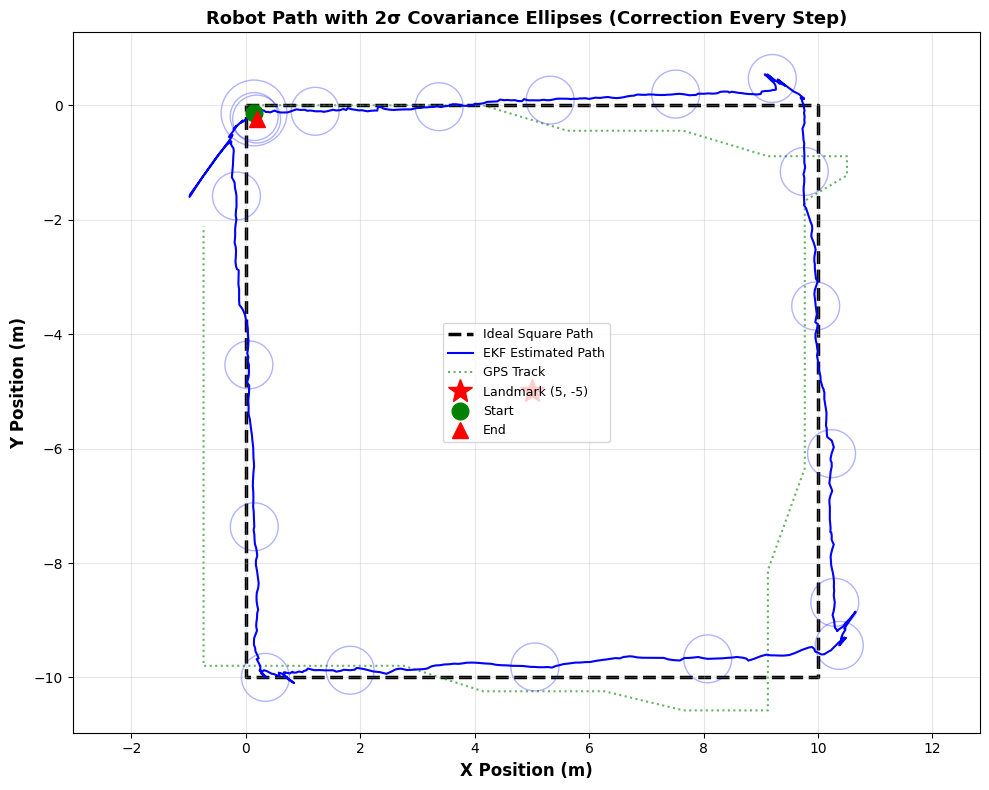


Generating other plots for every step correction...


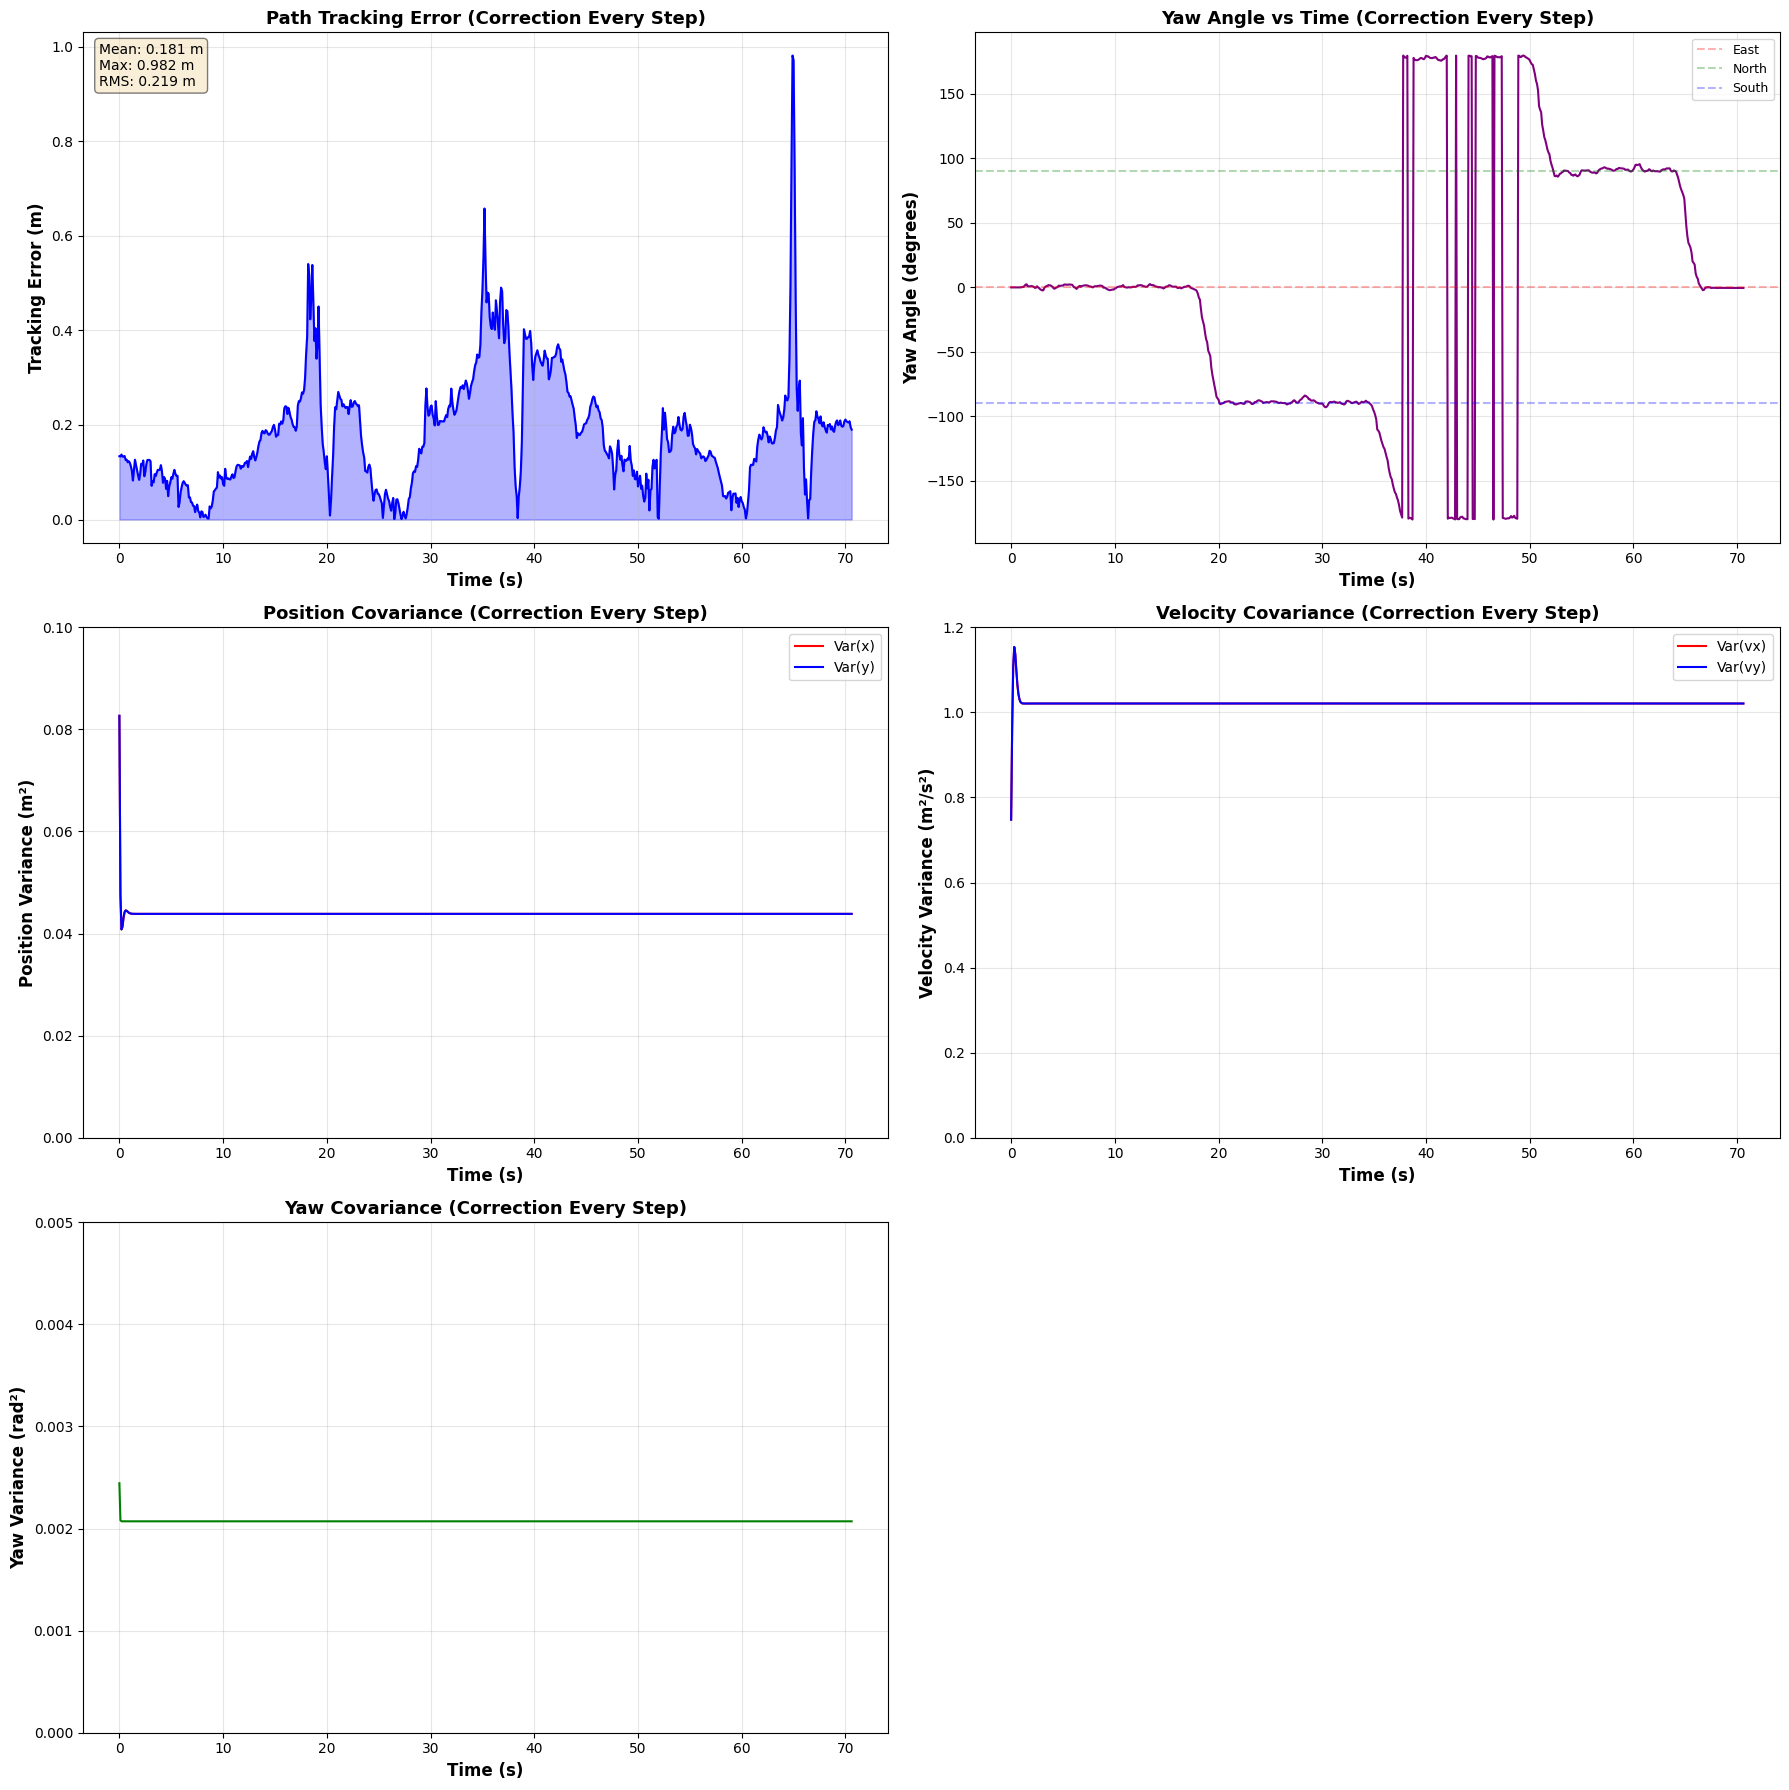


RUN 2: CORRECTION EVERY OTHER TIME STEP

RUNNING EKF - Correction Every Other Step

✓ EKF initialized
  Initial state: [0. 0. 0. 0. 0.]
  Processing 707 time steps...
  Progress: 100/707 (14.1%)者に「
✓ EKF complete!
  Progress: 200/707 (28.3%)者に「
✓ EKF complete!
  Progress: 300/707 (42.4%)者に「
✓ EKF complete!
  Progress: 400/707 (56.6%)者に「
✓ EKF complete!
  Progress: 500/707 (70.7%)者に「
✓ EKF complete!
  Progress: 600/707 (84.9%)者に「
✓ EKF complete!
  Progress: 700/707 (99.0%)者に「
✓ EKF complete!

--------------------------------------------------------------------------------
RESULTS SUMMARY
--------------------------------------------------------------------------------
Mean tracking error:  0.176 m
Max tracking error:   0.992 m
RMS tracking error:   0.218 m
Final position:       (0.20, -0.24) m
Final yaw:            -0.4°
Final position std:   σ_x=0.244 m, σ_y=0.244 m
--------------------------------------------------------------------------------

Generating path plot for every other st

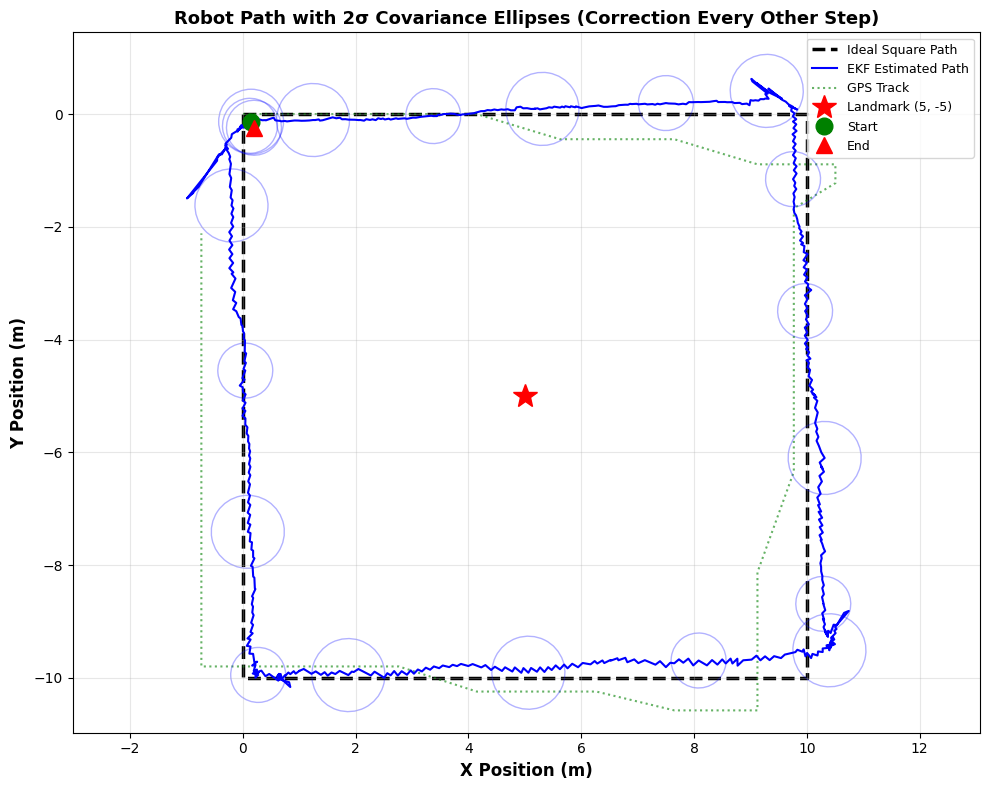


Generating other plots for every other step correction...


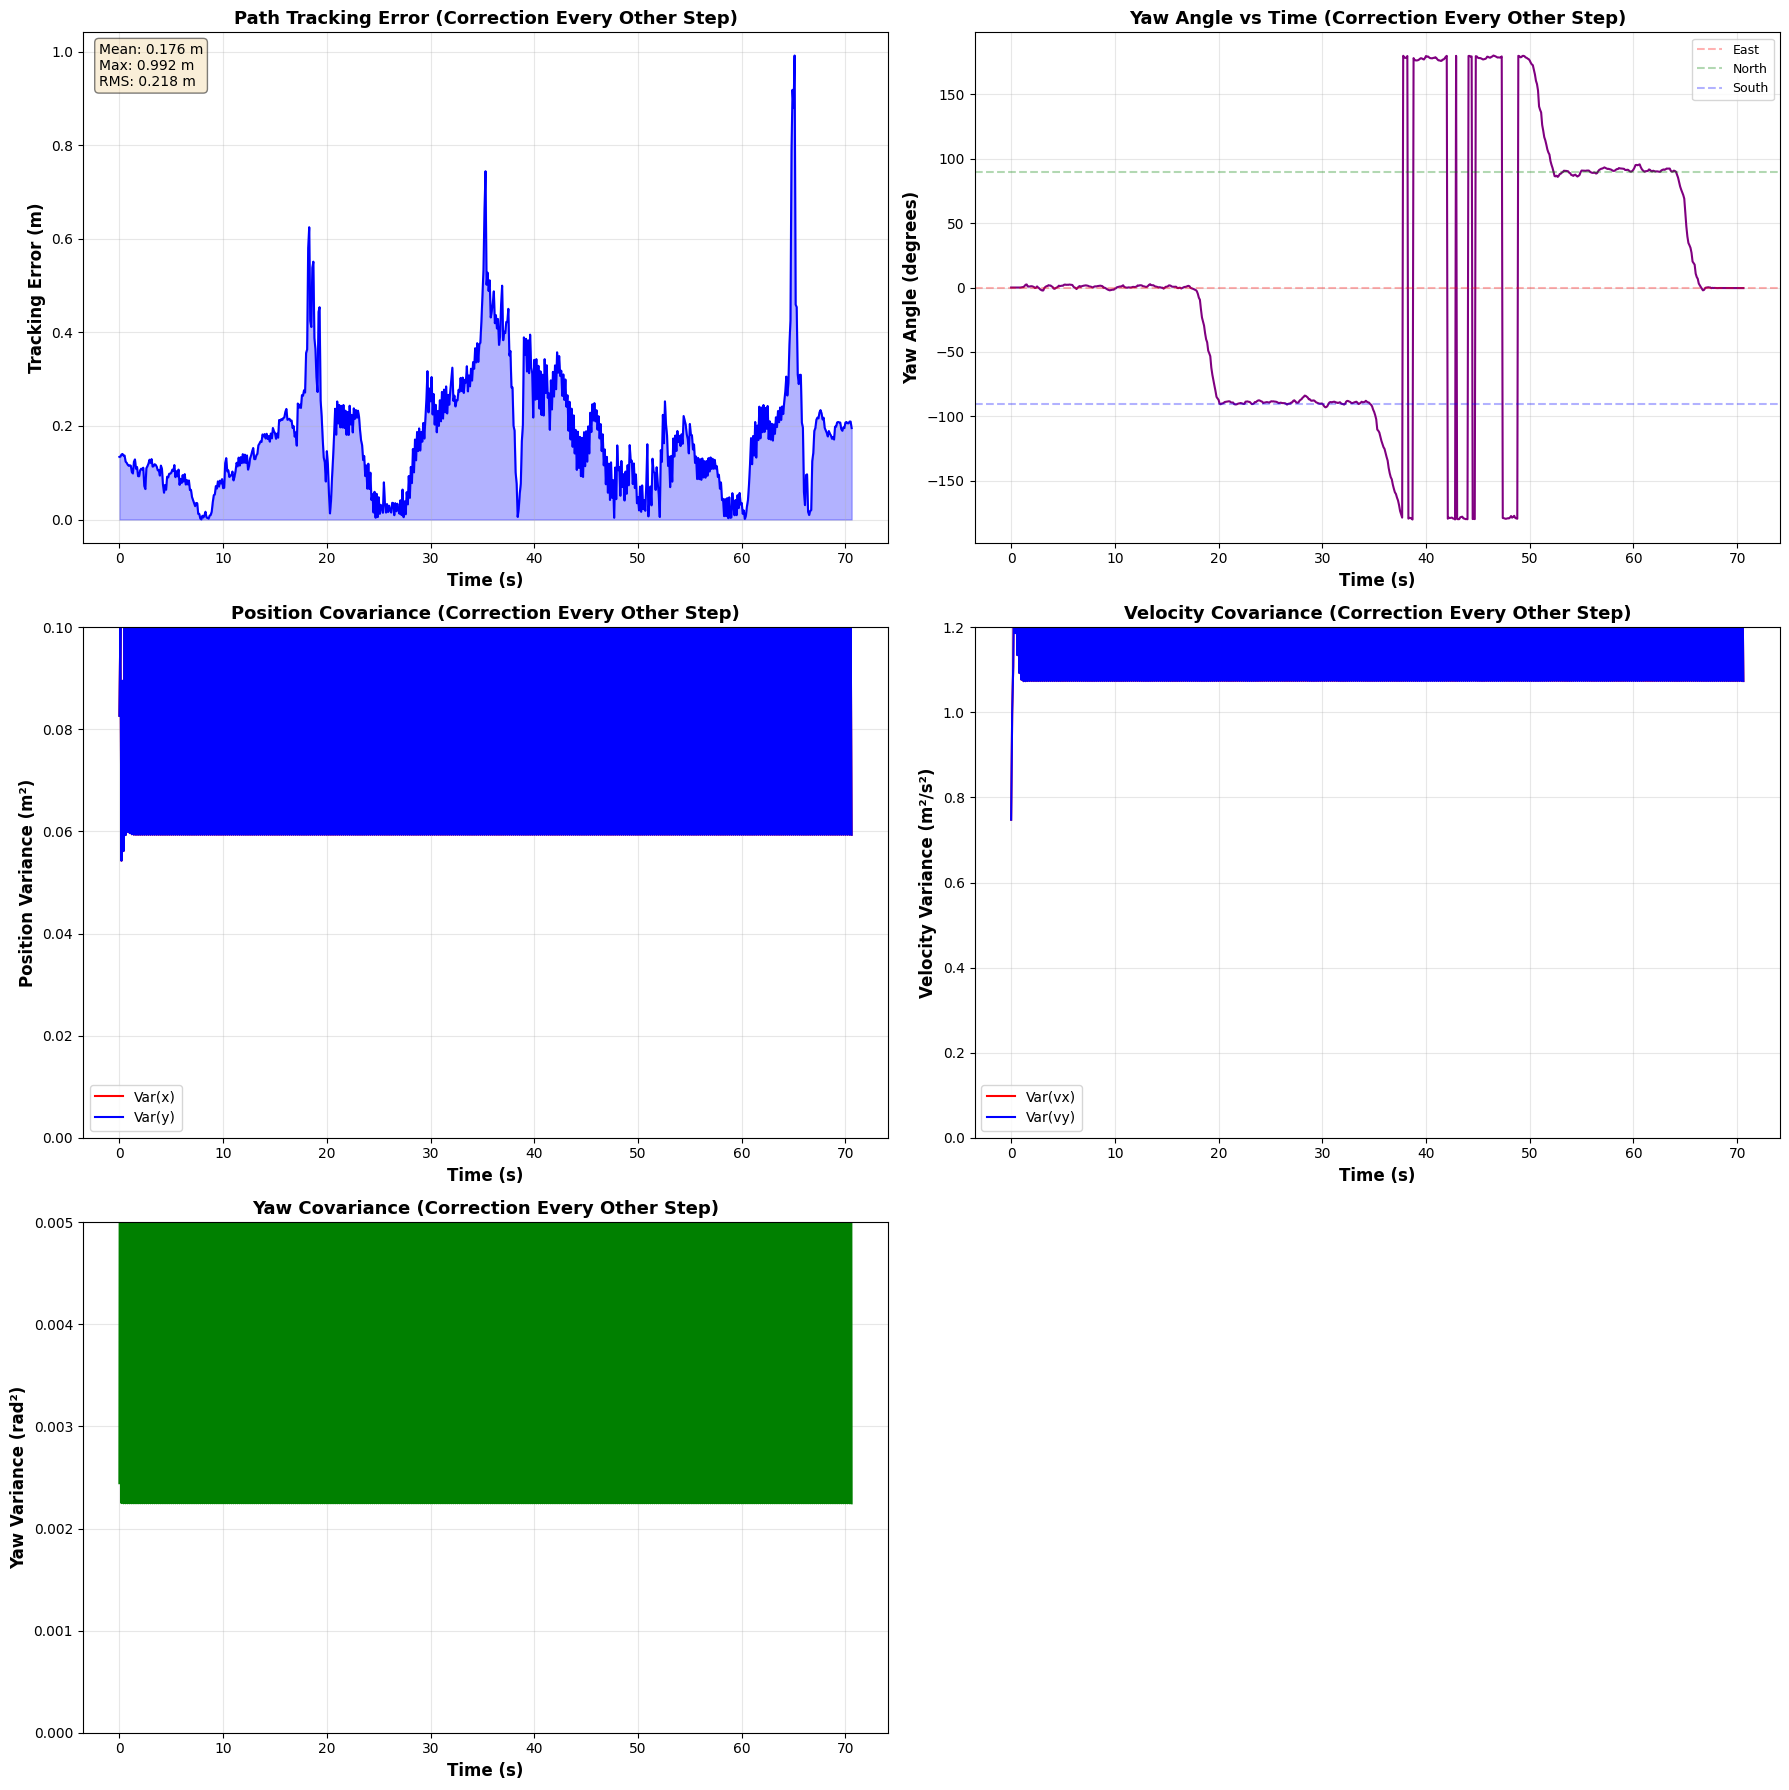


COMPARISON: Every Step vs Every Other Step

Tracking Error Statistics:
Metric                    Every Step      Every Other     Difference     
--------------------------------------------------------------------------------
Mean Error (m)            0.1806          0.1762          0.0045         
Max Error (m)             0.9816          0.9918          0.0101         
RMS Error (m)             0.2190          0.2178          0.0012         

Final Covariance (Uncertainty):
State                     Every Step      Every Other     Ratio          
--------------------------------------------------------------------------------
Var(x (m²))               0.043859        0.059355        1.35           x
Var(y (m²))               0.043859        0.059355        1.35           x
Var(vx (m²/s²))           1.020900        1.073772        1.05           x
Var(vy (m²/s²))           1.020900        1.073772        1.05           x
Var(theta (rad²))         0.002071        0.002247        1.09 

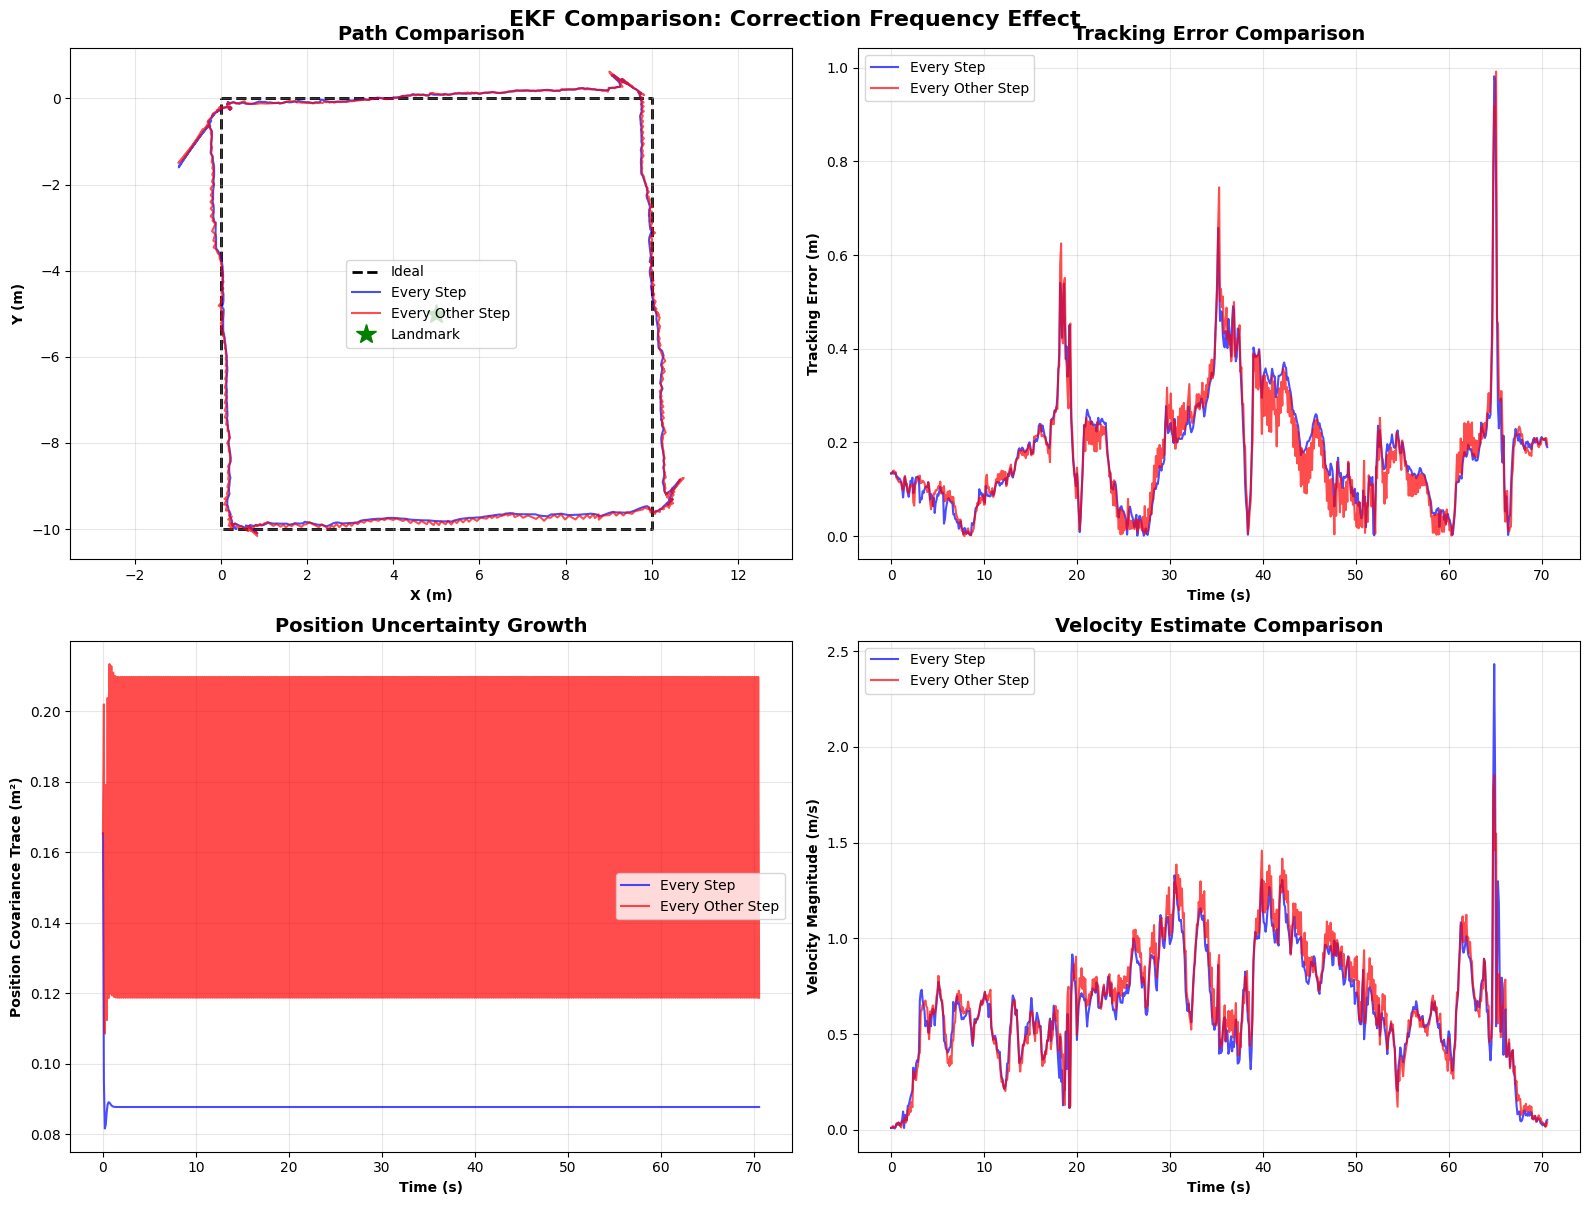

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import warnings
warnings.filterwarnings("ignore")

# =============================================================================
# SECTION 4: EKF IMPLEMENTATION
# =============================================================================

class EKFLocalizer:
    """
    Extended Kalman Filter for Robot Localization

    State Vector (Hint 1 - 5x1):
        x = [x, y, vx, vy, theta]^T
        where:s
            x, y:     Robot position in global frame (meters)
            vx, vy:   Robot velocity in global frame (m/s)
            theta:    Robot yaw angle (radians, CCW positive from East)

    Motion Model (Section 2, Hint 4):
        Uses IMU accelerations and yaw velocity as inputs
        Non-holonomic constraint (no lateral slip)

    Measurement Model (Section 2, Hint 5):
        Direct measurements of [x, y, theta] from Lidar + IMU
    """

    def __init__(self, initial_state=None):
        """
        Initialize the EKF

        Parameters:
        -----------
        initial_state : np.array, optional
            Initial state [x, y, vx, vy, theta]
            If None, starts at origin with zero velocity
        """
        # The robot starts at the north west corner of the square path
        # Robot heads east (theta = 0)
        # Assuming square is centered at landmark (5, -5), NW corner is at (0, 0)

        if initial_state is None:
            self.x = np.array([0.0, 0.0, 0.0, 0.0, 0.0])  # [x, y, vx, vy, theta]
        else:
            self.x = initial_state.copy()

        # State covariance matrix P (5x5)
        # Initially uncertain about position and velocity
        self.P = np.diag([1.0, 1.0, 0.5, 0.5, 0.1])

        # Process noise covariance Q (5x5)
        self.Q = np.diag([
            PROCESS_NOISE_STD['x']**2,
            PROCESS_NOISE_STD['y']**2,
            PROCESS_NOISE_STD['vx']**2,
            PROCESS_NOISE_STD['vy']**2,
            PROCESS_NOISE_STD['theta']**2
        ])

        # Measurement noise covariance R (3x3)
        # We measure [x, y, theta] directly
        self.R = np.diag([
            MEASUREMENT_NOISE_STD['x']**2,
            MEASUREMENT_NOISE_STD['y']**2,
            MEASUREMENT_NOISE_STD['theta']**2
        ])

        # Identity matrix for updates
        self.I = np.eye(state_dim)


    def predict(self, accel_x, accel_y, omega):
        """
        EKF Prediction Step

        Section 2: "Use IMU measurements for prediction step"
        - Forward and lateral acceleration (double integrated)
        - Yaw velocity (omega) as control input

            vx,t = vx,t-1 + ax,t*cos(θt-1)*δt
            vy,t = vy,t-1 + ax,t*sin(θt-1)*δt

        Robot is non-holonomic and has no lateral slip

        Parameters:
        -----------
        accel_x : float
            Forward acceleration in robot frame (m/s²)
        accel_y : float
            Lateral acceleration in robot frame (m/s²)
        omega : float
            Yaw rate (rad/s)

        Returns:
        --------
        np.array : Predicted state
        """
        # Extract current state
        x_pos = self.x[0]
        y_pos = self.x[1]
        vx = self.x[2]
        vy = self.x[3]
        theta = self.x[4]

        # Transform accelerations from robot frame to global frame
        # Robot frame: x forward, y left
        # Global frame: x east, y north
        ax_global = accel_x * np.cos(theta) - accel_y * np.sin(theta)
        ay_global = accel_x * np.sin(theta) + accel_y * np.cos(theta)

        # Update velocities (Hint 4 equations)
        vx_new = vx + ax_global * dT
        vy_new = vy + ay_global * dT

        # Update positions (integrate velocity)
        x_new = x_pos + vx * dT + 0.5 * ax_global * dT**2
        y_new = y_pos + vy * dT + 0.5 * ay_global * dT**2

        # Update yaw (integrate yaw velocity)
        # Wrap angle after update
        theta_new = wrap_to_pi(theta + omega * dT)

        # Predicted state
        x_pred = np.array([x_new, y_new, vx_new, vy_new, theta_new])

        # Compute Jacobian of motion model F
        F = self.compute_motion_jacobian(accel_x, accel_y, vx, vy, theta)

        # Predict covariance: P = F*P*F^T + Q
        # ensure that you're using the matrix multiplication function
        self.P = F @ self.P @ F.T + self.Q

        # Update state
        self.x = x_pred

        return self.x


    def compute_motion_jacobian(self, accel_x, accel_y, vx, vy, theta):
        """
        Compute Jacobian of motion model with respect to state

        The motion model is:
            x_new = x + vx*dt + 0.5*ax_global*dt²
            y_new = y + vy*dt + 0.5*ay_global*dt²
            vx_new = vx + ax_global*dt
            vy_new = vy + ay_global*dt
            theta_new = theta + omega*dt

        where ax_global and ay_global depend on theta

        Double-check your dimensions of all matrices

        Parameters:
        -----------
        accel_x, accel_y : float
            Accelerations in robot frame
        vx, vy : float
            Current velocities
        theta : float
            Current yaw angle

        Returns:
        --------
        np.array : Jacobian matrix F (5x5)
        """
        F = np.eye(state_dim )

        # Derivatives of global accelerations with respect to theta
        dax_dtheta = -accel_x * np.sin(theta) - accel_y * np.cos(theta)
        day_dtheta = accel_x * np.cos(theta) - accel_y * np.sin(theta)

        # ∂x/∂vx = dt
        F[0, 2] = dT

        # ∂x/∂theta = 0.5 * dax_dtheta * dT**2
        F[0, 4] = 0.5 * dax_dtheta * dT**2

        # ∂y/∂vy = dt
        F[1, 3] = dT

        # ∂y/∂theta = 0.5 * day_dtheta * dT**2
        F[1, 4] = 0.5 * day_dtheta * dT**2

        # ∂vx/∂theta = dax_dtheta * dT
        F[2, 4] = dax_dtheta * dT

        # ∂vy/∂theta = day_dtheta * dT
        F[3, 4] = day_dtheta * dT

        # Theta dynamics are independent: ∂theta/∂theta = 1
        # (Already set by identity matrix)

        return F


    def correct(self, z_x, z_y, z_theta):
        """
        EKF Correction Step

        Section 2: "Correction step uses:"
        - "Robot's local coordinate frame Lidar measurement (x,y) of the pylon"
        - "Robot's IMU yaw angle measurement"

        After transformation, we have direct measurements of [x, y, theta]

        Parameters:
        -----------
        z_x : float
            x position measurement (meters)
        z_y : float
            y position measurement (meters)
        z_theta : float
            Yaw measurement (radians)

        Returns:
        --------
        np.array : Corrected state
        """
        # Measurement vector z = [z_x, z_y, z_theta]
        z = np.array([z_x, z_y, z_theta])

        # Predicted measurement from current state
        h_pred = np.array([self.x[0], self.x[1], self.x[4]])

        # Innovation (measurement residual)
        y_innov = z - h_pred

        # Hint 2: MUST wrap angle difference!
        y_innov[2] = wrap_to_pi(y_innov[2])

        # Measurement Jacobian H
        # Since we measure x, y, theta directly:
        # h(x) = [x, y, theta]
        # H = ∂h/∂x
        H = np.zeros((3, state_dim ))
        H[0, 0] = 1.0  # ∂h_x/∂x
        H[1, 1] = 1.0  # ∂h_y/∂y
        H[2, 4] = 1.0  # ∂h_theta/∂theta

        # Innovation covariance: S = H*P*H^T + R
        # Lab Note: "ensure that you're using the matrix multiplication function"
        S = H @ self.P @ H.T + self.R

        # Kalman gain: K = P*H^T*S^(-1)
        # Lab Note: "ensure that you're using... matrix inverse function"
        K = self.P @ H.T @ np.linalg.inv(S)

        # Update state: x = x + K*y
        self.x = self.x + K @ y_innov

        # Hint 2: Wrap yaw angle after update
        self.x[4] = wrap_to_pi(self.x[4])

        # Update covariance: P = (I - K*H)*P
        self.P = (self.I - K @ H) @ self.P

        return self.x


print("\n✓ EKF class defined")


# =============================================================================
# SECTION 5: VISUALIZATION FUNCTIONS
# =============================================================================

def plot_covariance_ellipse(ax, mean, cov, n_std=2.0, **kwargs):
    """
    Plot covariance ellipse for 2D Gaussian

    Parameters:
    -----------
    ax : matplotlib axis
    mean : array-like
        Mean [x, y]
    cov : np.array
        2x2 covariance matrix
    n_std : float
        Number of standard deviations (default: 2σ ≈ 95% confidence)
    """
    eigvals, eigvecs = np.linalg.eigh(cov)
    angle = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))
    width, height = 2 * n_std * np.sqrt(eigvals)
    ellipse = Ellipse(mean, width, height, angle=angle, **kwargs)
    ax.add_patch(ellipse)


def compute_path_tracking_error(estimated_path, square_corners):
    """
    Compute distance from estimated path to ideal square path

    Section 3: "Plot the path tracking error (where error is the distance
    any point is from the square) as a function of time"

    Parameters:
    -----------
    estimated_path : np.array
        Nx2 array of [x, y] positions
    square_corners : list
        Square corner coordinates

    Returns:
    --------
    np.array : Error at each time step (meters)
    """
    n_points = len(estimated_path)
    errors = np.zeros(n_points)

    # Define square edges
    edges = []
    for i in range(len(square_corners)):
        p1 = square_corners[i]
        p2 = square_corners[(i + 1) % len(square_corners)]
        edges.append((p1, p2))

    # For each point, find minimum distance to any edge
    for i, point in enumerate(estimated_path):
        min_dist = float('inf')

        for p1, p2 in edges:
            # Compute distance from point to line segment
            p1 = np.array(p1)
            p2 = np.array(p2)
            point = np.array(point)

            # Vector from p1 to p2
            v = p2 - p1
            # Vector from p1 to point
            w = point - p1

            # Projection
            c1 = np.dot(w, v)
            if c1 <= 0:
                dist = np.linalg.norm(point - p1)
            else:
                c2 = np.dot(v, v)
                if c1 >= c2:
                    dist = np.linalg.norm(point - p2)
                else:
                    b = c1 / c2
                    proj = p1 + b * v
                    dist = np.linalg.norm(point - proj)

            min_dist = min(min_dist, dist)

        errors[i] = min_dist

    return errors

def plot_ekf_path_with_covariances(results, title_suffix="", show_gps=True):
    """
    Plots the EKF estimated path with covariance ellipses.
    This is the first plot from the original plot_ekf_results function, now separated.
    """
    states = results['states']
    covariances = results['covariances']

    x_est = states[:, 0]
    y_est = states[:, 1]

    # 10x10 meter square path located in the center of an open field
    # pylon at known location (5.0, -5.0)
    # Square centered at (5, -5) with 10m sides
    square_corners = [
        [0, 0],      # NW corner (starting position)
        [10, 0],     # NE corner
        [10, -10],   # SE corner
        [0, -10],    # SW corner
        [0, 0]       # Back to start
    ]

    fig, ax = plt.subplots(figsize=(10, 8))

    # Ideal square path
    sq_x = [c[0] for c in square_corners]
    sq_y = [c[1] for c in square_corners]
    ax.plot(sq_x, sq_y, 'k--', linewidth=2.5, label='Ideal Square Path', zorder=1)

    # EKF estimated path
    ax.plot(x_est, y_est, 'b-', linewidth=1.5, label='EKF Estimated Path', zorder=2)

    # GPS comparison (if available)
    if show_gps and results.get('has_gps', False):
        gps_x = results['gps_x']
        gps_y = results['gps_y']
        if gps_x is not None:
            ax.plot(gps_x, gps_y, 'g:', linewidth=1.5, alpha=0.6,
                    label='GPS Track', zorder=1)

    # Landmark
    ax.plot(x_landmark, y_landmark, 'r*', markersize=18,
            label=f'Landmark ({x_landmark}, {y_landmark})', zorder=5)

    # Start and end markers
    ax.plot(x_est[0], y_est[0], 'go', markersize=12, label='Start', zorder=4)
    ax.plot(x_est[-1], y_est[-1], 'r^', markersize=12, label='End', zorder=4)

    # Covariance ellipses (every 30 points)
    n_ellipses = min(20, len(states) // 30)
    ellipse_indices = np.linspace(0, len(states)-1, n_ellipses, dtype=int)
    for idx in ellipse_indices:
        cov_xy = covariances[idx][:2, :2]
        plot_covariance_ellipse(ax, [x_est[idx], y_est[idx]], cov_xy,
                               n_std=2.0, edgecolor='blue', facecolor='none',
                               alpha=0.3, linewidth=1)

    ax.set_xlabel('X Position (m)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Y Position (m)', fontsize=12, fontweight='bold')
    ax.set_title(f'Robot Path with 2σ Covariance Ellipses {title_suffix}',
                 fontsize=13, fontweight='bold')
    ax.legend(fontsize=9, loc='best')
    ax.grid(True, alpha=0.3)
    ax.axis('equal')
    plt.tight_layout()
    plt.show()
    return fig


def plot_ekf_results(results, title_suffix="", show_gps=True):
    """
    Create comprehensive plots for EKF results (excluding the path plot)

    Section 3 Requirements:
    - "Plot the path tracking error... as a function of time"
    - "Plot the yaw angle as a function of time in a different plot"
    - "Plot covariance matrix elements as a function of time"

    Parameters:
    -----------
    results : dict
        Dictionary with EKF results
    title_suffix : str
        Suffix for plot titles
    show_gps : bool
        Whether to show GPS comparison
    """
    states = results['states']
    covariances = results['covariances']
    times = results['time']
    errors = results['errors']

    # Extract trajectories
    theta_est = states[:, 4]

    # Create a single figure with 5 subplots
    fig, axes = plt.subplots(3, 2, figsize=(18, 18)) # 3 rows, 2 columns
    axes = axes.flatten() # Flatten to easily iterate

    # =========================================================================
    # PLOT 1: Path Tracking Error vs Time
    # =========================================================================
    ax1 = axes[0]
    ax1.plot(times, errors, 'b-', linewidth=1.5)
    ax1.fill_between(times, 0, errors, alpha=0.3, color='blue')
    ax1.set_xlabel('Time (s)', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Tracking Error (m)', fontsize=12, fontweight='bold')
    ax1.set_title(f'Path Tracking Error {title_suffix}', fontsize=13, fontweight='bold')
    ax1.grid(True, alpha=0.3)

    # Add statistics
    mean_error = np.mean(errors)
    max_error = np.max(errors)
    rms_error = np.sqrt(np.mean(errors**2))
    ax1.text(0.02, 0.98, f'Mean: {mean_error:.3f} m\nMax: {max_error:.3f} m\nRMS: {rms_error:.3f} m',
            transform=ax1.transAxes, fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    # =========================================================================
    # PLOT 2: Yaw Angle vs Time
    # =========================================================================
    ax2 = axes[1]
    ax2.plot(times, np.degrees(theta_est), 'purple', linewidth=1.5)
    ax2.set_xlabel('Time (s)', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Yaw Angle (degrees)', fontsize=12, fontweight='bold')
    ax2.set_title(f'Yaw Angle vs Time {title_suffix}', fontsize=13, fontweight='bold')
    ax2.grid(True, alpha=0.3)

    # Add reference lines for cardinal directions
    ax2.axhline(0, color='r', linestyle='--', alpha=0.3, label='East')
    ax2.axhline(90, color='g', linestyle='--', alpha=0.3, label='North')
    ax2.axhline(-90, color='b', linestyle='--', alpha=0.3, label='South')
    ax2.legend(fontsize=9)

    # =========================================================================
    # PLOTS 3-5: Covariance Elements vs Time
    # =========================================================================

    # Extract covariance diagonal elements
    cov_xx = np.array([P[0, 0] for P in covariances])
    cov_yy = np.array([P[1, 1] for P in covariances])
    cov_vxvx = np.array([P[2, 2] for P in covariances])
    cov_vyvy = np.array([P[3, 3] for P in covariances])
    cov_thetatheta = np.array([P[4, 4] for P in covariances])

    # Plot 3: Position Covariance
    ax3 = axes[2]
    ax3.plot(times, cov_xx, 'r-', linewidth=1.5, label='Var(x)')
    ax3.plot(times, cov_yy, 'b-', linewidth=1.5, label='Var(y)')
    ax3.set_xlabel('Time (s)', fontsize=12, fontweight='bold')
    ax3.set_ylabel('Position Variance (m²)', fontsize=12, fontweight='bold')
    ax3.set_title(f'Position Covariance {title_suffix}', fontsize=13, fontweight='bold')
    ax3.legend(fontsize=10)
    ax3.grid(True, alpha=0.3)
    ax3.set_ylim(0, 0.1)

    # Plot 4: Velocity Covariance
    ax4 = axes[3]
    ax4.plot(times, cov_vxvx, 'r-', linewidth=1.5, label='Var(vx)')
    ax4.plot(times, cov_vyvy, 'b-', linewidth=1.5, label='Var(vy)')
    ax4.set_xlabel('Time (s)', fontsize=12, fontweight='bold')
    ax4.set_ylabel('Velocity Variance (m²/s²)', fontsize=12, fontweight='bold')
    ax4.set_title(f'Velocity Covariance {title_suffix}', fontsize=13, fontweight='bold')
    ax4.legend(fontsize=10)
    ax4.grid(True, alpha=0.3)
    ax4.set_ylim(0, 1.2)

    # Plot 5: Yaw Covariance
    ax5 = axes[4]
    ax5.plot(times, cov_thetatheta, 'g-', linewidth=1.5)
    ax5.set_xlabel('Time (s)', fontsize=12, fontweight='bold')
    ax5.set_ylabel('Yaw Variance (rad²)', fontsize=12, fontweight='bold')
    ax5.set_title(f'Yaw Covariance {title_suffix}', fontsize=13, fontweight='bold')
    ax5.grid(True, alpha=0.3)
    ax5.set_ylim(0, 0.005)

    # Hide the empty 6th subplot if it exists
    if len(axes) > 5:
        fig.delaxes(axes[5])

    plt.tight_layout()
    plt.show()

    return fig


print("✓ Visualization functions defined")


# =============================================================================
# SECTION 6: RUN EKF
# =============================================================================

def run_ekf(data, run_correction_every_step=True, verbose=True):
    """
    Run the EKF localization filter

    Section 3: "Integrate your EKF in python or Matlab"

    Parameters:
    -----------
    data : dict
        Preprocessed data from load_and_preprocess_data()
    run_correction_every_step : bool
        If True: run correction at every time step
        If False: run correction every other time step (Section 3 requirement)
    verbose : bool
        Print progress messages

    Returns:
    --------
    dict : Results containing states, covariances, errors, etc.
    """
    if verbose:
        print("\n" + "="*80)
        mode = "Every Step" if run_correction_every_step else "Every Other Step"
        print(f"RUNNING EKF - Correction {mode}")
        print("="*80)

    n_points = data['n_points']

    # Initialize EKF
    # Robot starts at the north west corner and heads east
    initial_state = np.array([0.0, 0.0, 0.0, 0.0, 0.0])  # [x, y, vx, vy, theta]
    ekf = EKFLocalizer(initial_state=initial_state)

    # Storage
    states = np.zeros((n_points, state_dim))
    covariances = []

    if verbose:
        print(f"\n✓ EKF initialized")
        print(f"  Initial state: {initial_state}")
        print(f"  Processing {n_points} time steps...")

    # Main EKF loop
    for i in range(n_points):
        # =====================================================================
        # PREDICTION STEP (always run)
        # =====================================================================
        # Section 2: "Use IMU measurements for prediction step"

        accel_x = data['accel_x'][i]
        accel_y = data['accel_y'][i]
        omega = data['omega'][i]

        ekf.predict(accel_x, accel_y, omega)

        # =====================================================================
        # CORRECTION STEP (frequency depends on mode)
        # =====================================================================
        # Section 3: "Run your filter again, but only call your correction step
        # every other time step, while calling your prediction step at every time step"

        should_correct = run_correction_every_step or (i % 2 == 0)

        if should_correct:
            z_x = data['z_x'][i]
            z_y = data['z_y'][i]
            z_theta = data['z_theta'][i]

            ekf.correct(z_x, z_y, z_theta)

        # Store results
        states[i] = ekf.x.copy()
        covariances.append(ekf.P.copy())

        # Progress indicator
        if verbose and (i + 1) % 100 == 0:
            print(f"  Progress: {i+1}/{n_points} ({100*(i+1)/n_points:.1f}%)者に「\n✓ EKF complete!")

    # =========================================================================
    # Compute tracking errors
    # =========================================================================
    square_corners = [[0, 0], [10, 0], [10, -10], [0, -10]]
    estimated_positions = states[:, :2]
    errors = compute_path_tracking_error(estimated_positions, square_corners)

    # =========================================================================
    # Package results
    # =========================================================================
    results = {
        'states': states,
        'covariances': covariances,
        'time': data['time'],
        'errors': errors,
        'run_correction_every_step': run_correction_every_step,
        'gps_x': data['gps_x'],
        'gps_y': data['gps_y'],
        'has_gps': data['has_gps']
    }

    # Print summary statistics
    if verbose:
        print("\n" + "-"*80)
        print("RESULTS SUMMARY")
        print("-"*80)
        print(f"Mean tracking error:  {np.mean(errors):.3f} m")
        print(f"Max tracking error:   {np.max(errors):.3f} m")
        print(f"RMS tracking error:   {np.sqrt(np.mean(errors**2)):.3f} m")
        print(f"Final position:       ({states[-1, 0]:.2f}, {states[-1, 1]:.2f}) m")
        print(f"Final yaw:            {np.degrees(states[-1, 4]):.1f}°")
        print(f"Final position std:   σ_x={np.sqrt(covariances[-1][0,0]):.3f} m, σ_y={np.sqrt(covariances[-1][1,1]):.3f} m")
        print("-"*80)

    return results


print("✓ Main EKF function defined")


# =============================================================================
# SECTION 7: MAIN EXECUTION
# =============================================================================

print("\n" + "="*80)
print("READY TO RUN LAB 3 EKF!")
print("="*80)
print("\nTo execute the lab:")
print("1. Set the path to your filtered CSV file below")
print("2. Run the cells in order")
print("3. Results will be generated for both correction modes")
print("="*80)

# IMPORTANT: Set your data file path here!
# Example: DATA_FILE = "/content/drive/MyDrive/E205LABS/E205Lab3/2020_2_26__17_21_59_filtered.csv"
DATA_FILE = "/content/drive/MyDrive/E205/E205LABS/E205Lab3/2020_2_26__17_21_59_filtered.csv"

print(f"\n Data file: {DATA_FILE}")
print("\n  If the path above is incorrect, update the DATA_FILE variable and re-run")
# =============================================================================
# EXECUTION CELL 1: Load and Preprocess Data
# =============================================================================
# Run this cell first to load your data

# Load and preprocess the data
data = load_and_preprocess_data(DATA_FILE)

# Verify the measurements look correct
print("\nQuick validation of measurements:")
print(f"  z_x forms a box? Width = {np.max(data['z_x']) - np.min(data['z_x']):.2f}m (expect ~10m)")
print(f"  z_y forms a box? Height = {np.max(data['z_y']) - np.min(data['z_y']):.2f}m (expect ~10m)")

if (np.max(data['z_x']) - np.min(data['z_x'])) > 7 and (np.max(data['z_y']) - np.min(data['z_y'])) > 7:
    print("\n Data looks good! Proceed to run EKF.")
else:
    print("\n  Warning: Measurements may not form a proper box!")
    print("   Check your CSV file path and column assignments.")


# =============================================================================
# EXECUTION CELL 2: Run EKF with Correction Every Step
# =============================================================================
# Section 3: First run with correction at every time step

print("\n" + "="*80)
print("RUN 1: CORRECTION AT EVERY TIME STEP")
print("="*80)

results_every = run_ekf(data, run_correction_every_step=True, verbose=True)

# Generate path plot
print("\nGenerating path plot for every step correction...")
fig1_path = plot_ekf_path_with_covariances(results_every, title_suffix="(Correction Every Step)", show_gps=True)

# Generate other plots
print("\nGenerating other plots for every step correction...")
fig1_other = plot_ekf_results(results_every, title_suffix="(Correction Every Step)", show_gps=True)


# =============================================================================
# EXECUTION CELL 3: Run EKF with Correction Every Other Step
# =============================================================================
# Section 3: "Run your filter again, but only call your correction step
# every other time step, while calling your prediction step at every time step"

print("\n" + "="*80)
print("RUN 2: CORRECTION EVERY OTHER TIME STEP")
print("="*80)

results_alternate = run_ekf(data, run_correction_every_step=False, verbose=True)

# Generate path plot
print("\nGenerating path plot for every other step correction...")
fig2_path = plot_ekf_path_with_covariances(results_alternate, title_suffix="(Correction Every Other Step)", show_gps=True)

# Generate other plots
print("\nGenerating other plots for every other step correction...")
fig2_other = plot_ekf_results(results_alternate, title_suffix="(Correction Every Other Step)", show_gps=True)


# =============================================================================
# EXECUTION CELL 4: Comparison
# =============================================================================
# Compare the two runs

print("\n" + "="*80)
print("COMPARISON: Every Step vs Every Other Step")
print("="*80)

print("\nTracking Error Statistics:")
print(f"{'Metric':<25} {'Every Step':<15} {'Every Other':<15} {'Difference':<15}")
print("-"*80)

mean_err_every = np.mean(results_every['errors'])
mean_err_alt = np.mean(results_alternate['errors'])
print(f"{'Mean Error (m)':<25} {mean_err_every:<15.4f} {mean_err_alt:<15.4f} {abs(mean_err_every-mean_err_alt):<15.4f}")

max_err_every = np.max(results_every['errors'])
max_err_alt = np.max(results_alternate['errors'])
print(f"{'Max Error (m)':<25} {max_err_every:<15.4f} {max_err_alt:<15.4f} {abs(max_err_every-max_err_alt):<15.4f}")

rms_err_every = np.sqrt(np.mean(results_every['errors']**2))
rms_err_alt = np.sqrt(np.mean(results_alternate['errors']**2))
print(f"{'RMS Error (m)':<25} {rms_err_every:<15.4f} {rms_err_alt:<15.4f} {abs(rms_err_every-rms_err_alt):<15.4f}")

print("\nFinal Covariance (Uncertainty):")
print(f"{'State':<25} {'Every Step':<15} {'Every Other':<15} {'Ratio':<15}")
print("-"*80)

cov_every_final = results_every['covariances'][-1]
cov_alt_final = results_alternate['covariances'][-1]

for i, name in enumerate(['x (m²)', 'y (m²)', 'vx (m²/s²)', 'vy (m²/s²)', 'theta (rad²)']):
    val_every = cov_every_final[i, i]
    val_alt = cov_alt_final[i, i]
    ratio = val_alt / val_every if val_every > 0 else 0
    print(f"{'Var(' + name + ')':<25} {val_every:<15.6f} {val_alt:<15.6f} {ratio:<15.2f}x")

print("\nCovariance Trace (Total Uncertainty):")
trace_every = np.trace(cov_every_final)
trace_alt = np.trace(cov_alt_final)
print(f"  Every Step:       {trace_every:.6f}")
print(f"  Every Other Step: {trace_alt:.6f}")
print(f"  Ratio:            {trace_alt/trace_every:.2f}x")

print("\n" + "="*80)
print("LAB 3 EKF LOCALIZATION COMPLETE!")
print("="*80)
print("\n✓ All required plots have been generated")
print("✓ Statistics computed for both correction frequencies")
print("\nFor your report, discuss:")
print("  1. How the correction frequency affects tracking accuracy")
print("  2. How covariance grows differently between the two methods")
print("  3. The trade-off between computational efficiency and accuracy")
print("="*80)


# =============================================================================
# OPTIONAL: Additional Visualization
# =============================================================================
# Create a side-by-side comparison plot

def plot_comparison(results_every, results_alternate):
    """Create side-by-side comparison of the two runs"""

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # Extract data
    states_every = results_every['states']
    states_alt = results_alternate['states']
    time = results_every['time']

    # Ideal square
    square_x = [0, 10, 10, 0, 0]
    square_y = [0, 0, -10, -10, 0]

    # Plot 1: Paths comparison
    ax1 = axes[0, 0]
    ax1.plot(square_x, square_y, 'k--', linewidth=2, label='Ideal', zorder=1)
    ax1.plot(states_every[:, 0], states_every[:, 1], 'b-', linewidth=1.5,
            label='Every Step', alpha=0.7, zorder=2)
    ax1.plot(states_alt[:, 0], states_alt[:, 1], 'r-', linewidth=1.5,
            label='Every Other Step', alpha=0.7, zorder=2)
    ax1.plot(x_landmark, y_landmark, 'g*', markersize=15, label='Landmark', zorder=3)
    ax1.set_xlabel('X (m)', fontweight='bold')
    ax1.set_ylabel('Y (m)', fontweight='bold')
    ax1.set_title('Path Comparison', fontsize=14, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.axis('equal')

    # Plot 2: Tracking errors
    ax2 = axes[0, 1]
    ax2.plot(time, results_every['errors'], 'b-', linewidth=1.5,
            label='Every Step', alpha=0.7)
    ax2.plot(time, results_alternate['errors'], 'r-', linewidth=1.5,
            label='Every Other Step', alpha=0.7)
    ax2.set_xlabel('Time (s)', fontweight='bold')
    ax2.set_ylabel('Tracking Error (m)', fontweight='bold')
    ax2.set_title('Tracking Error Comparison', fontsize=14, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # Plot 3: Position covariance trace
    ax3 = axes[1, 0]
    trace_every = [np.trace(P[:2, :2]) for P in results_every['covariances']]
    trace_alt = [np.trace(P[:2, :2]) for P in results_alternate['covariances']]
    ax3.plot(time, trace_every, 'b-', linewidth=1.5, label='Every Step', alpha=0.7)
    ax3.plot(time, trace_alt, 'r-', linewidth=1.5, label='Every Other Step', alpha=0.7)
    ax3.set_xlabel('Time (s)', fontweight='bold')
    ax3.set_ylabel('Position Covariance Trace (m²)', fontweight='bold')
    ax3.set_title('Position Uncertainty Growth', fontsize=14, fontweight='bold')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    # Plot 4: Velocity magnitude
    ax4 = axes[1, 1]
    vel_every = np.sqrt(states_every[:, 2]**2 + states_every[:, 3]**2)
    vel_alt = np.sqrt(states_alt[:, 2]**2 + states_alt[:, 3]**2)
    ax4.plot(time, vel_every, 'b-', linewidth=1.5, label='Every Step', alpha=0.7)
    ax4.plot(time, vel_alt, 'r-', linewidth=1.5, label='Every Other Step', alpha=0.7)
    ax4.set_xlabel('Time (s)', fontweight='bold')
    ax4.set_ylabel('Velocity Magnitude (m/s)', fontweight='bold')
    ax4.set_title('Velocity Estimate Comparison', fontsize=14, fontweight='bold')
    ax4.legend()
    ax4.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.suptitle('EKF Comparison: Correction Frequency Effect',
                fontsize=16, fontweight='bold', y=1.00)
    plt.show()

    return fig

# Generate comparison plot
print("\nGenerating comparison visualization...")
fig_comp = plot_comparison(results_every, results_alternate)


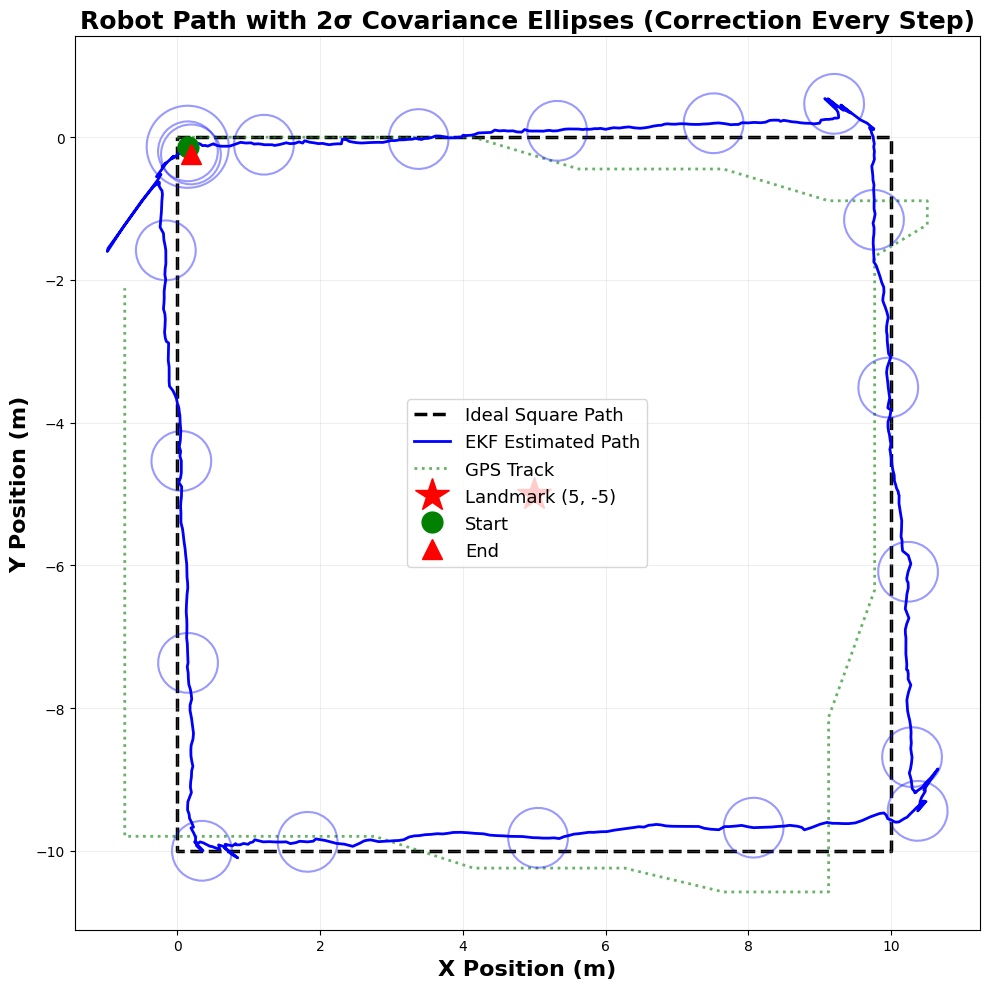

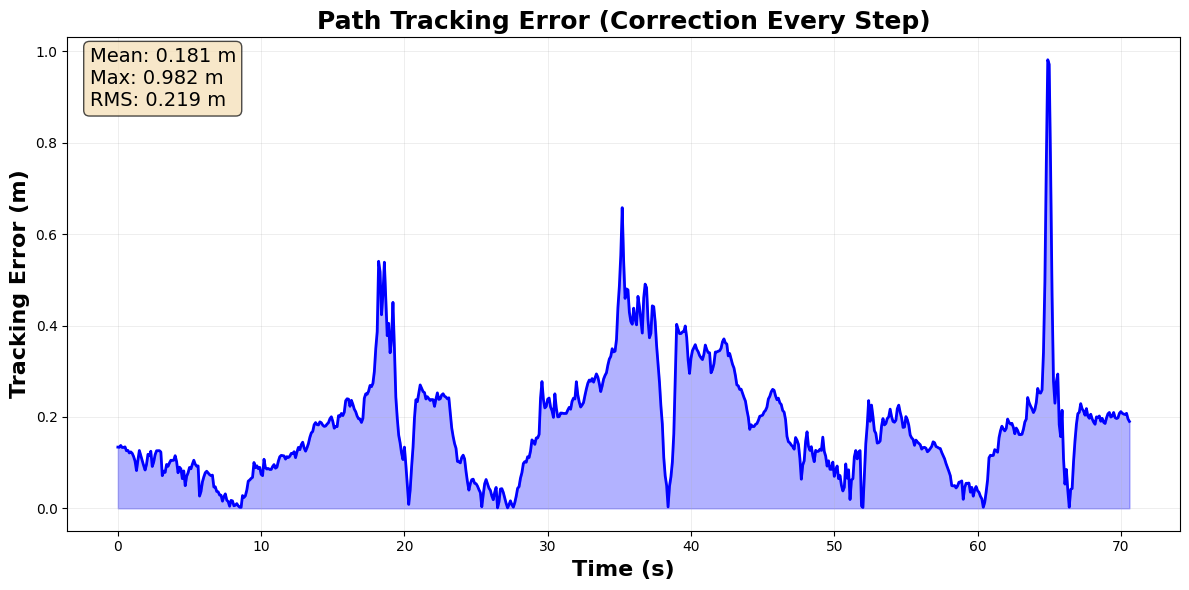

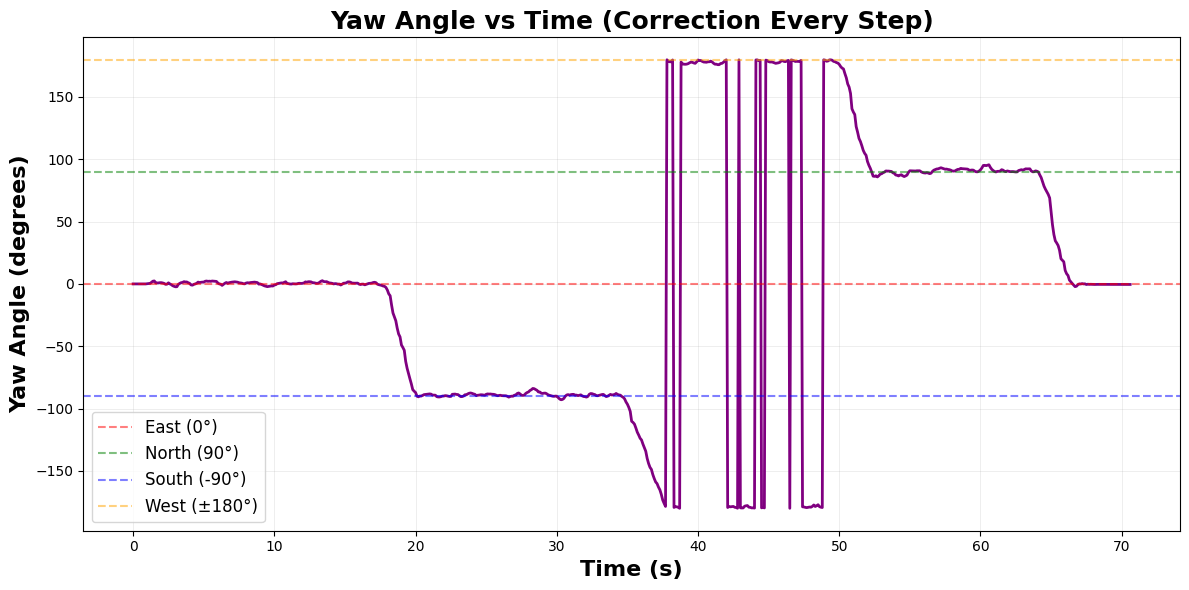

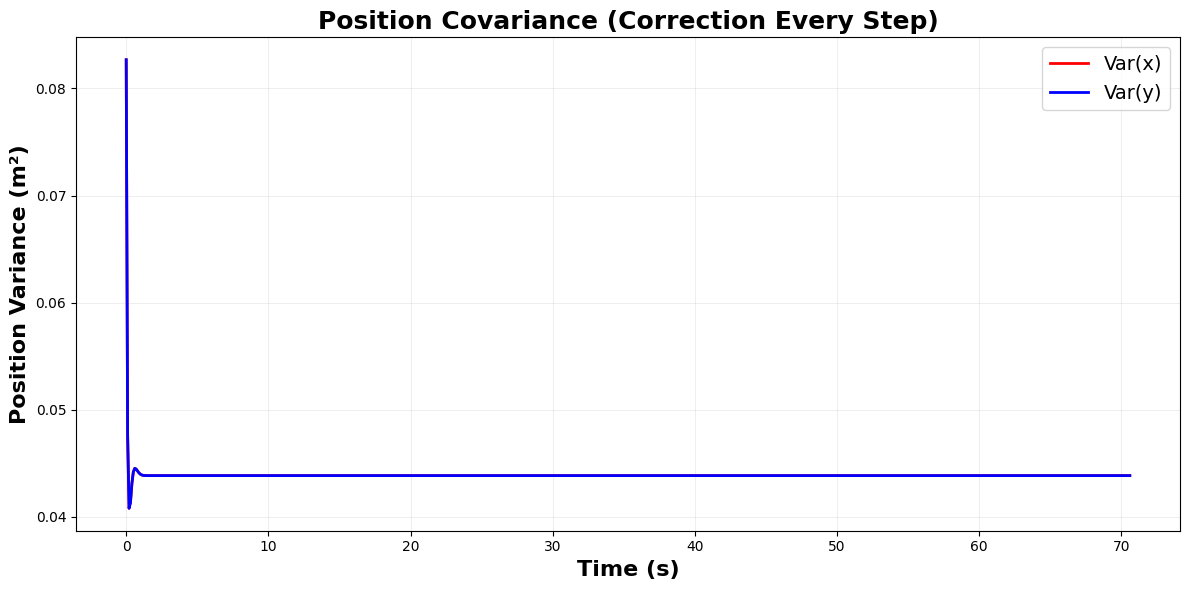

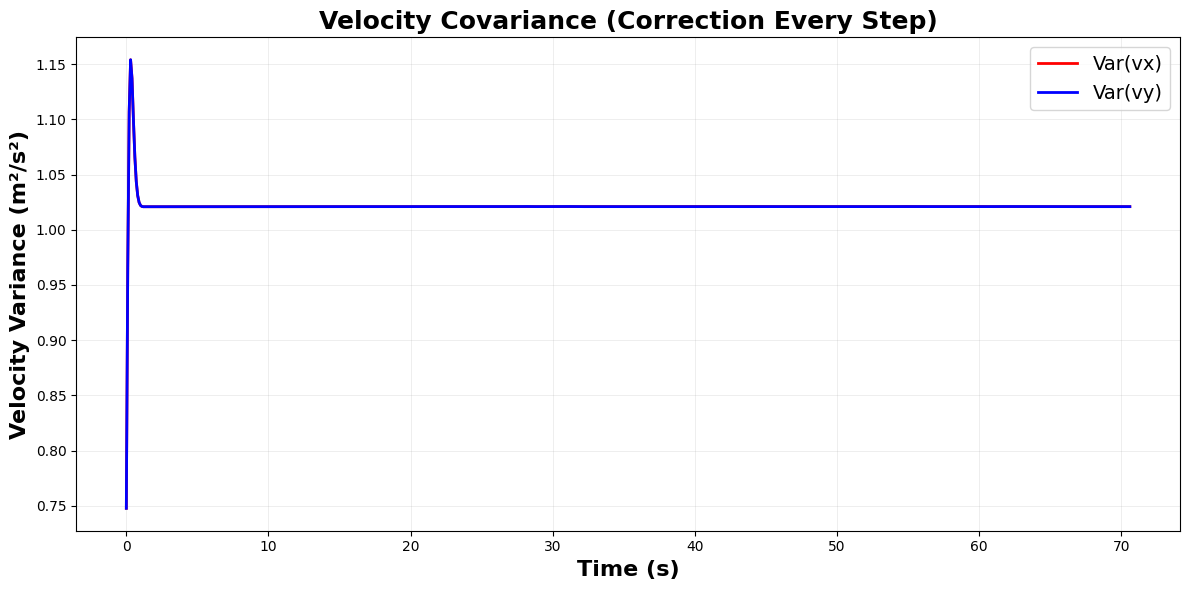

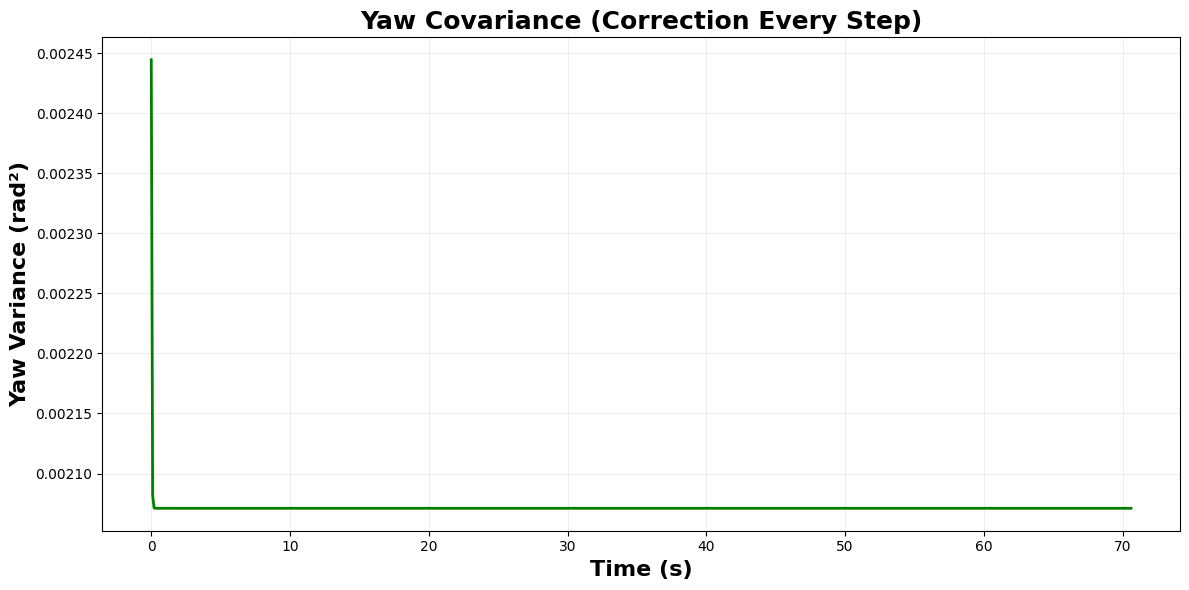

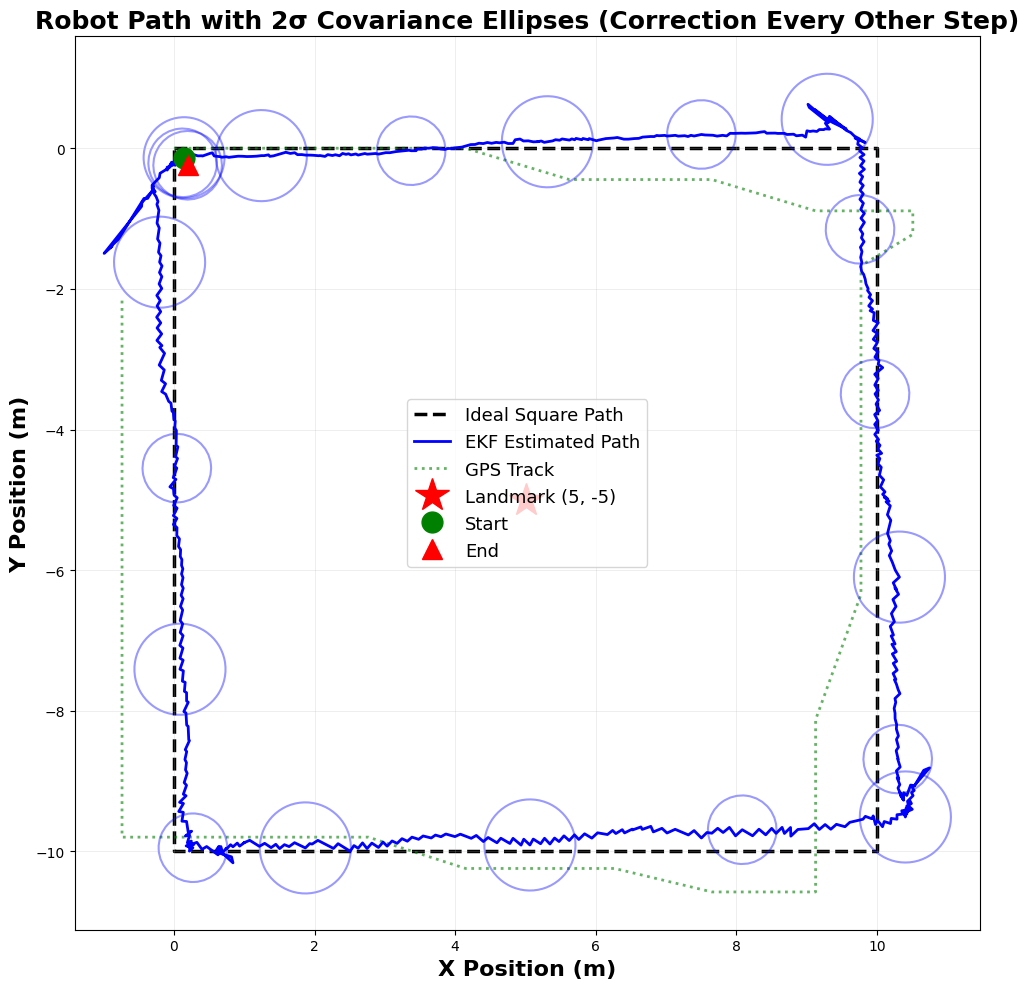

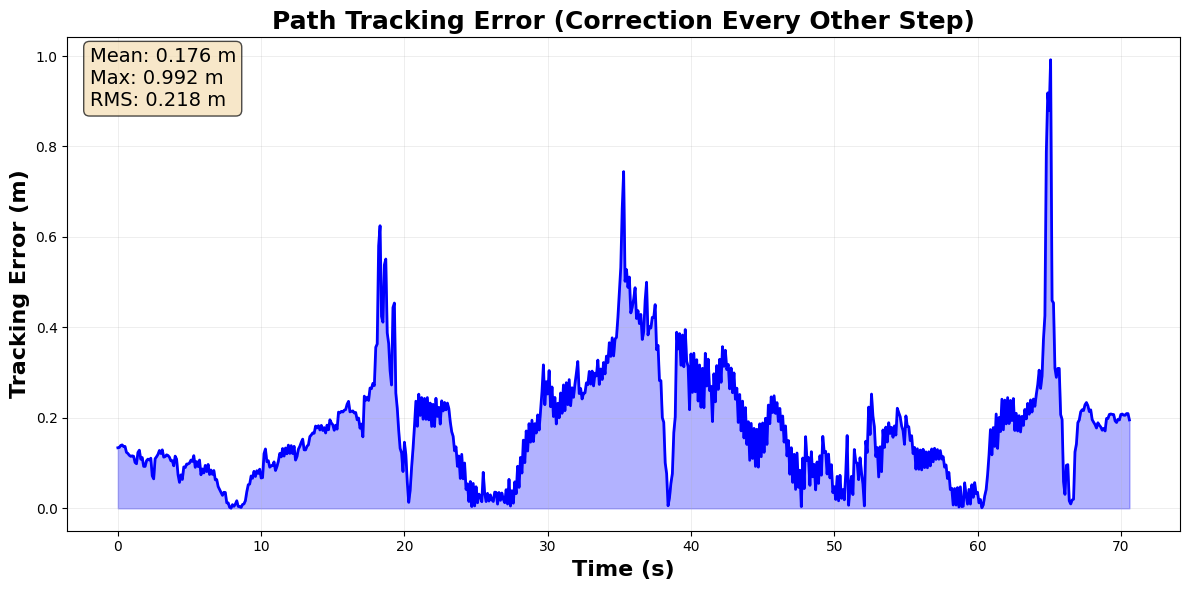

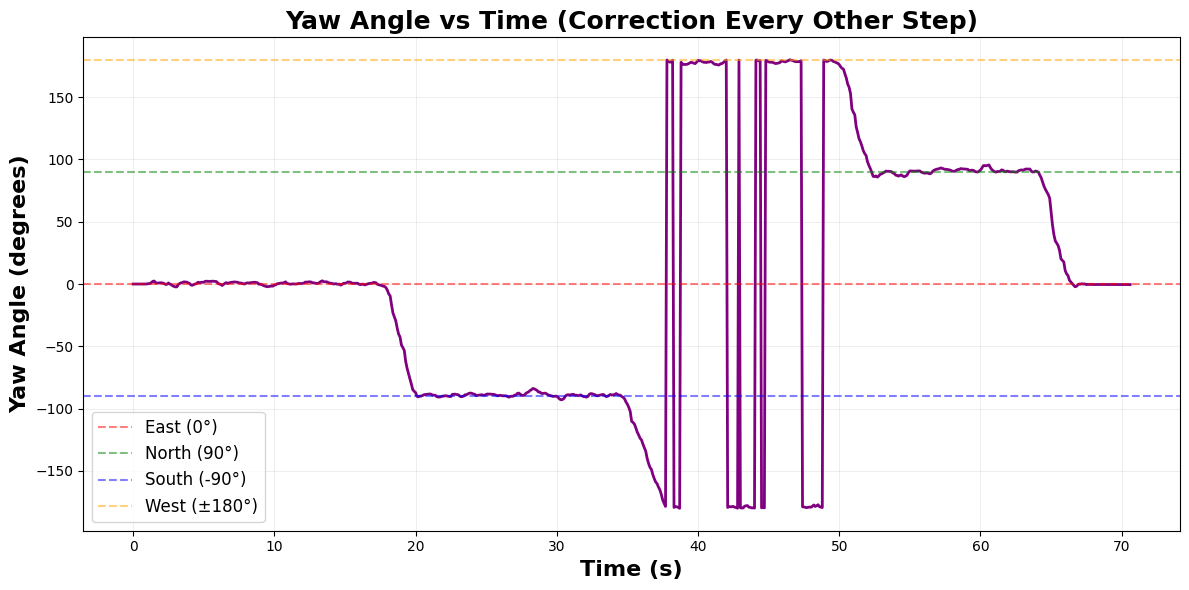

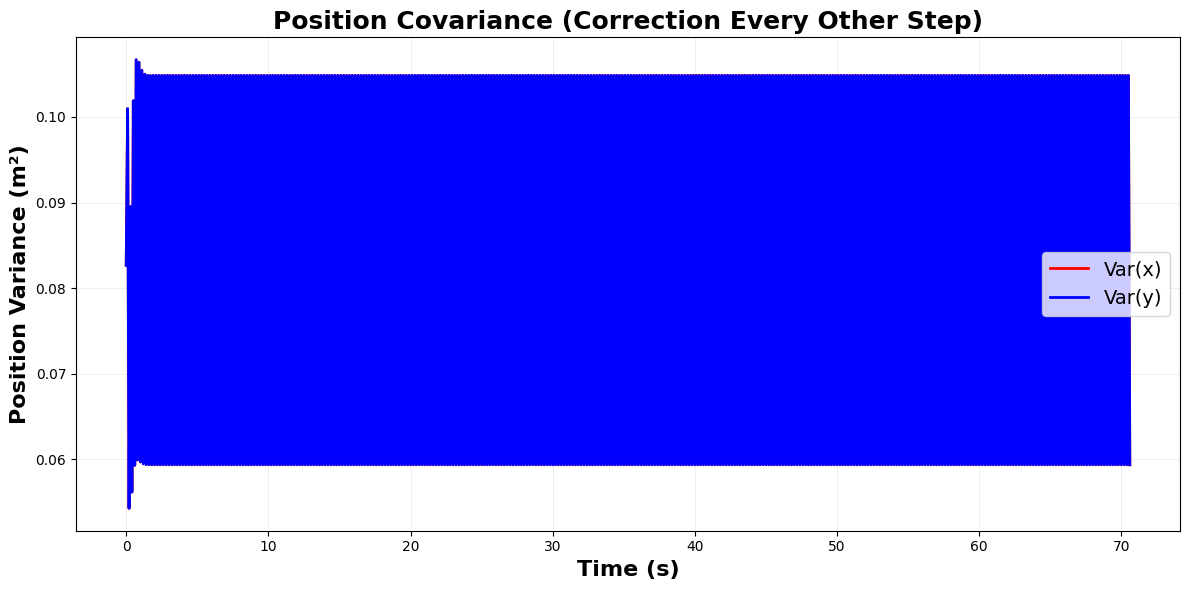

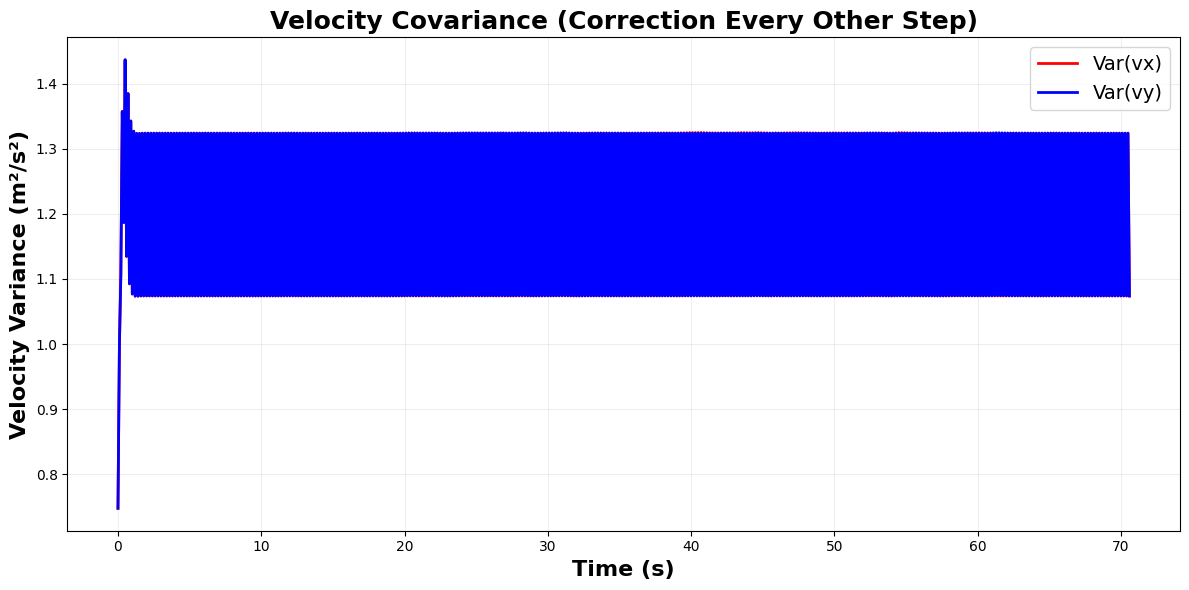

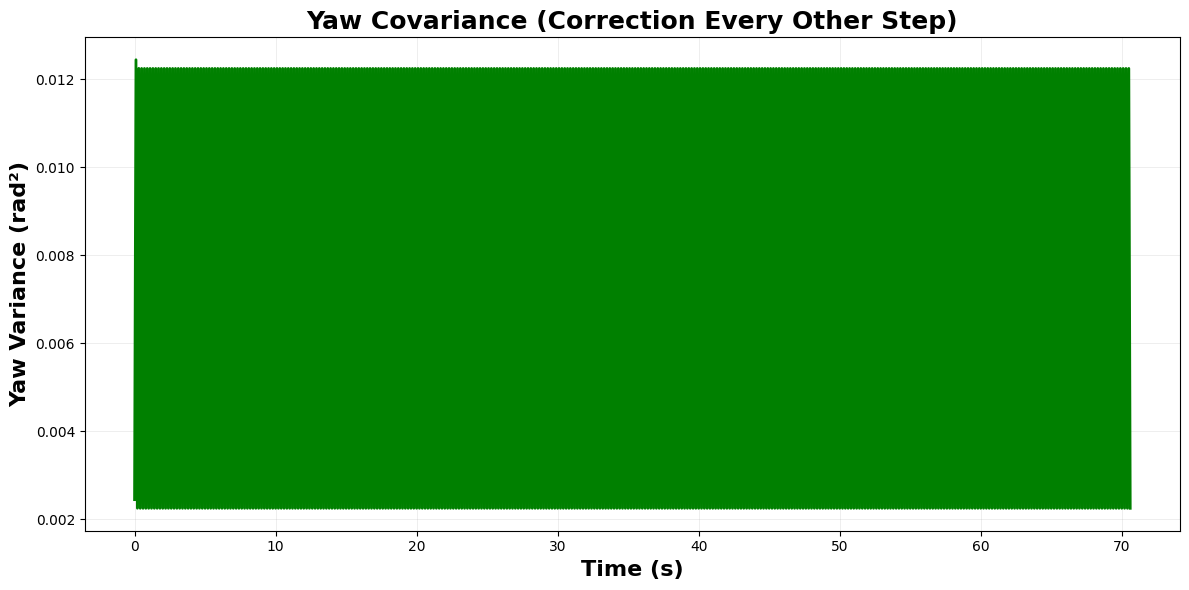

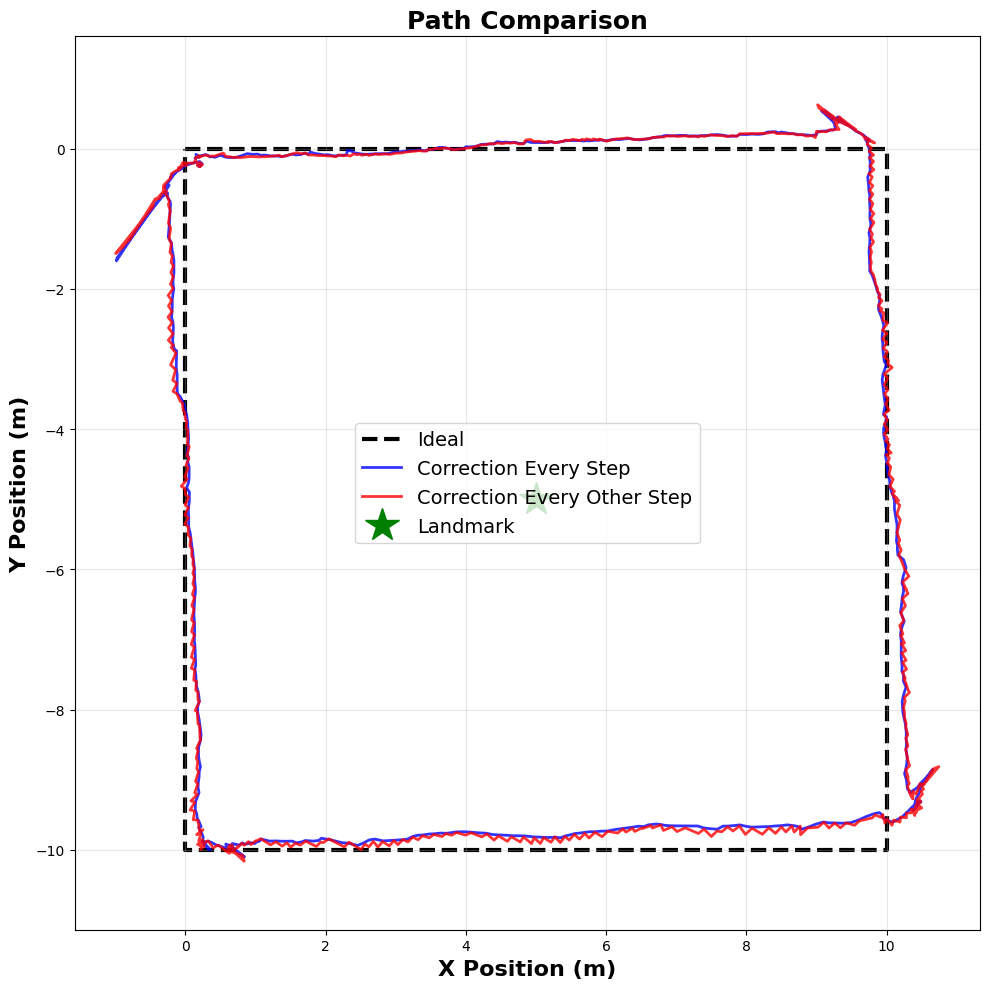

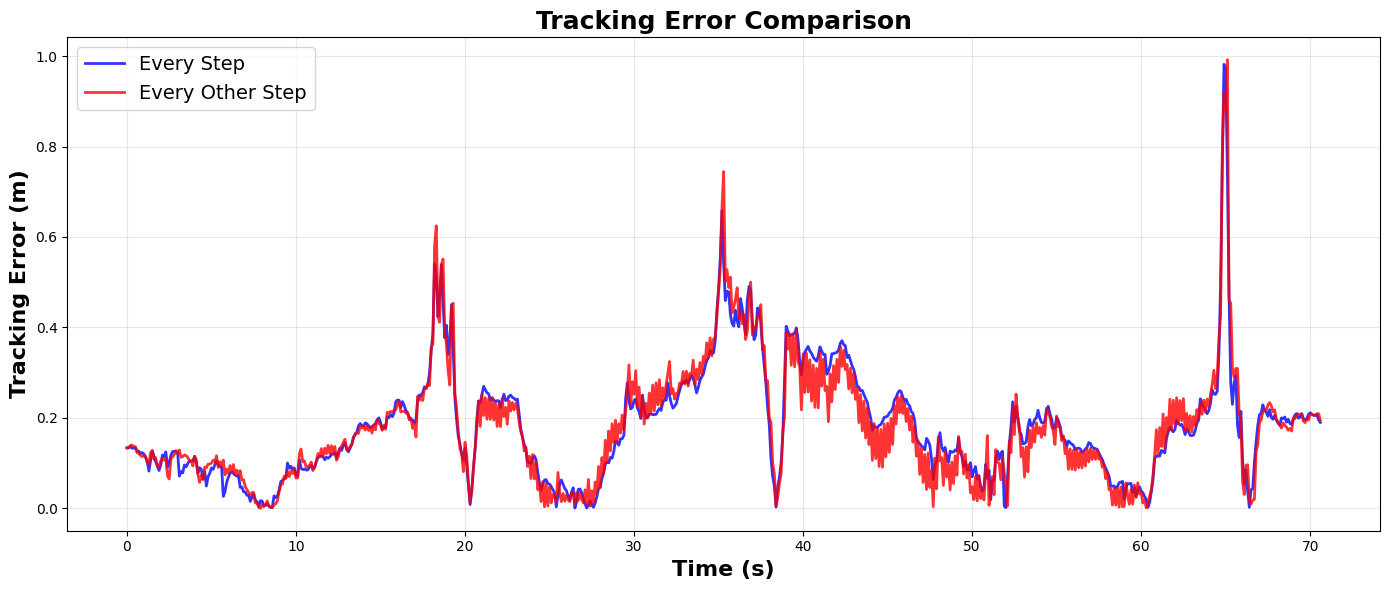

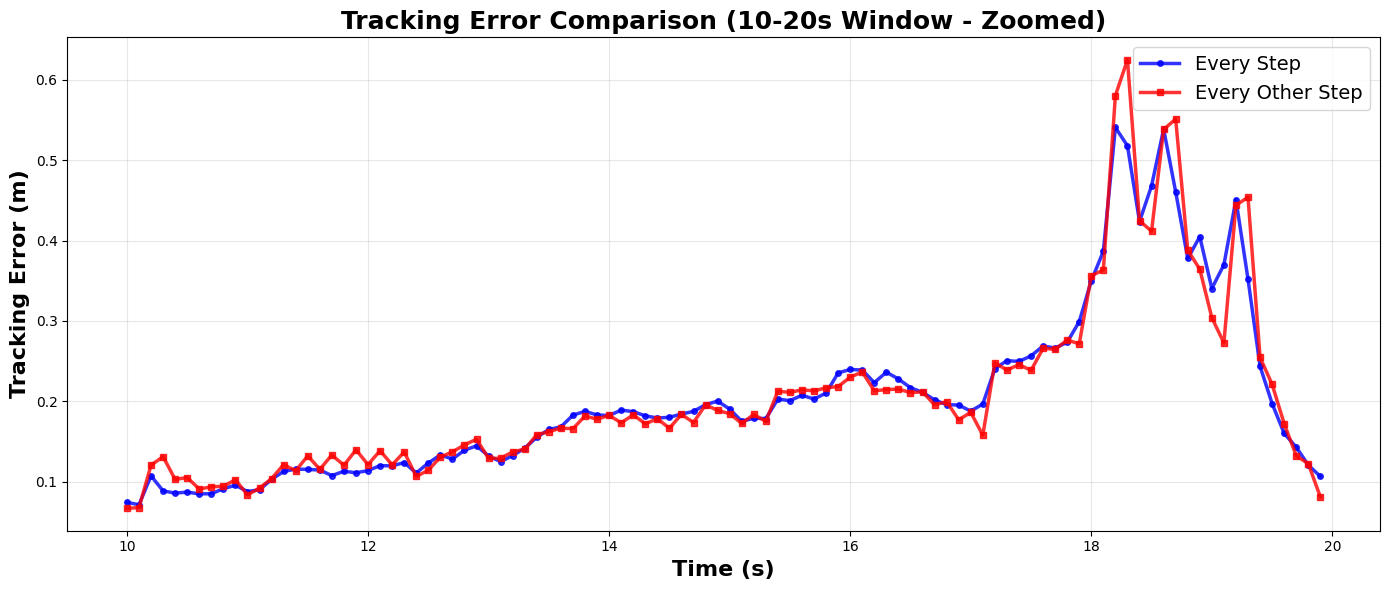

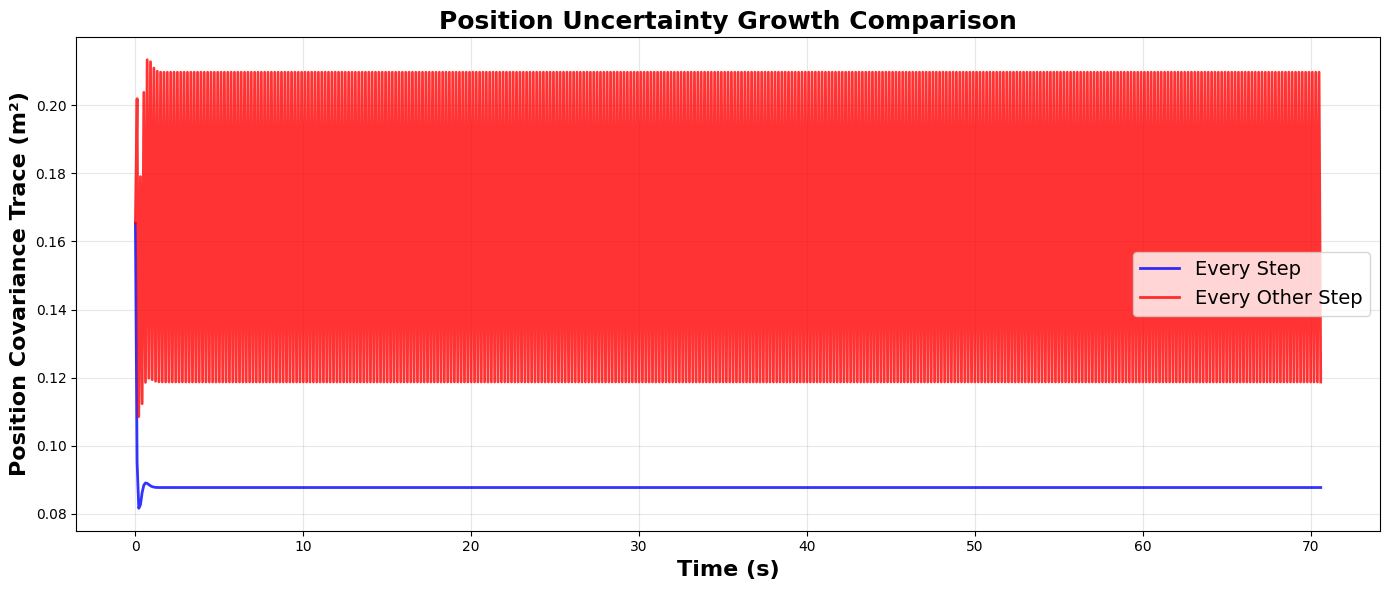

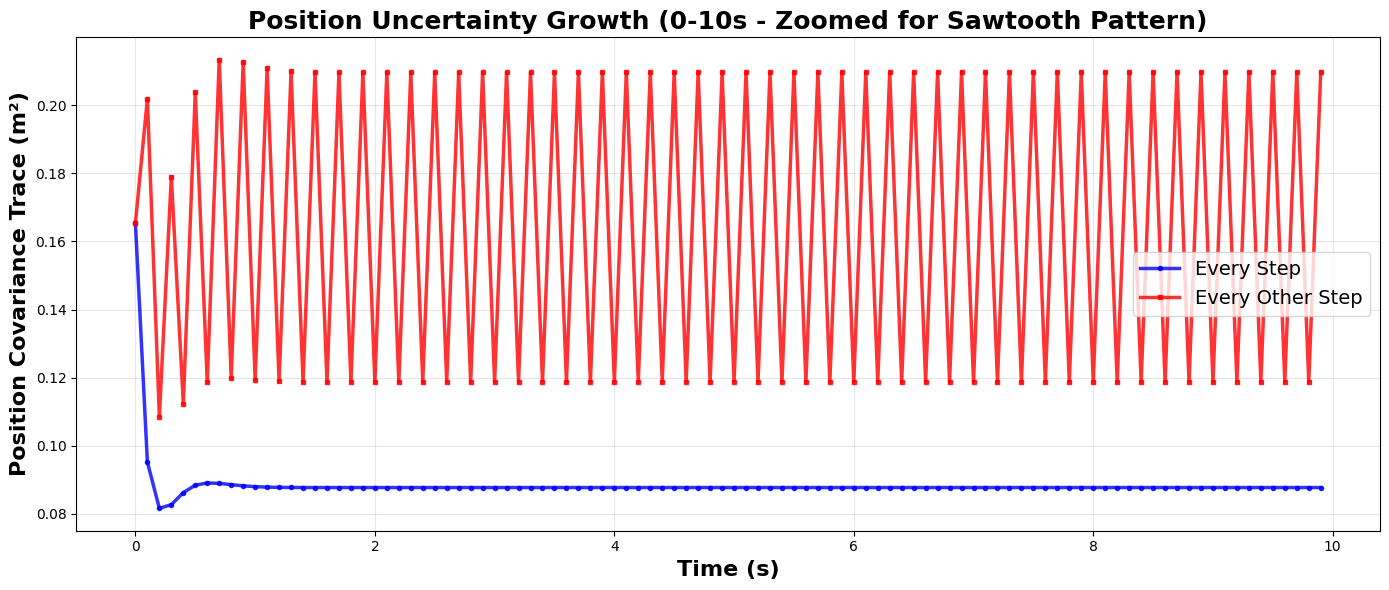

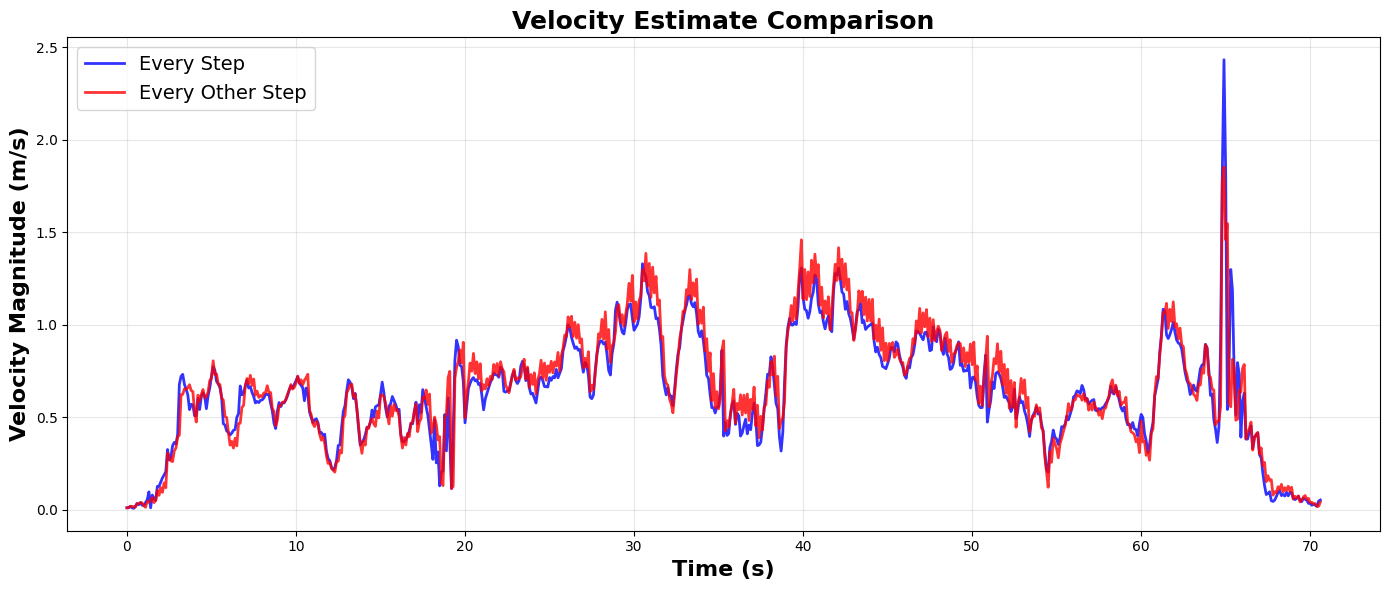

(<Figure size 1000x1000 with 1 Axes>,
 <Figure size 1400x600 with 1 Axes>,
 <Figure size 1400x600 with 1 Axes>,
 <Figure size 1400x600 with 1 Axes>,
 <Figure size 1400x600 with 1 Axes>,
 <Figure size 1400x600 with 1 Axes>)

In [16]:
# =============================================================================
# INDIVIDUAL PLOT GENERATION
# =============================================================================
# This generates each plot as a separate figure for cleaner presentation

def plot_ekf_results_individual(results, title_suffix="", show_gps=True):
    """
    Create individual plots for EKF results (not subplots)

    Each plot is generated separately for better clarity and formatting
    """
    states = results['states']
    covariances = results['covariances']
    times = results['time']
    errors = results['errors']

    # Extract trajectories
    x_est = states[:, 0]
    y_est = states[:, 1]
    theta_est = states[:, 4]

    # Square corners
    square_corners = [
        [0, 0], [10, 0], [10, -10], [0, -10], [0, 0]
    ]
    sq_x = [c[0] for c in square_corners]
    sq_y = [c[1] for c in square_corners]

    # Extract covariance diagonal elements
    cov_xx = np.array([P[0, 0] for P in covariances])
    cov_yy = np.array([P[1, 1] for P in covariances])
    cov_vxvx = np.array([P[2, 2] for P in covariances])
    cov_vyvy = np.array([P[3, 3] for P in covariances])
    cov_thetatheta = np.array([P[4, 4] for P in covariances])

    # =========================================================================
    # PLOT 1: Robot Path with Covariance Ellipses
    # =========================================================================
    fig1, ax = plt.subplots(1, 1, figsize=(10, 10))

    # Ideal square
    ax.plot(sq_x, sq_y, 'k--', linewidth=2.5, label='Ideal Square Path', zorder=1)

    # EKF path
    ax.plot(x_est, y_est, 'b-', linewidth=2, label='EKF Estimated Path', zorder=2)

    # GPS if available
    if show_gps and results.get('has_gps', False):
        gps_x = results['gps_x']
        gps_y = results['gps_y']
        if gps_x is not None:
            ax.plot(gps_x, gps_y, 'g:', linewidth=2, alpha=0.6,
                   label='GPS Track', zorder=1)

    # Landmark
    ax.plot(x_landmark, y_landmark, 'r*', markersize=25,
           label=f'Landmark ({x_landmark}, {y_landmark})', zorder=5)

    # Start and end
    ax.plot(x_est[0], y_est[0], 'go', markersize=15, label='Start', zorder=4)
    ax.plot(x_est[-1], y_est[-1], 'r^', markersize=15, label='End', zorder=4)

    # Covariance ellipses
    n_ellipses = 20
    ellipse_indices = np.linspace(0, len(states)-1, n_ellipses, dtype=int)
    for idx in ellipse_indices:
        cov_xy = covariances[idx][:2, :2]
        plot_covariance_ellipse(ax, [x_est[idx], y_est[idx]], cov_xy,
                               n_std=2.0, edgecolor='blue', facecolor='none',
                               alpha=0.4, linewidth=1.5)

    ax.set_xlabel('X Position (m)', fontsize=16, fontweight='bold')
    ax.set_ylabel('Y Position (m)', fontsize=16, fontweight='bold')
    ax.set_title(f'Robot Path with 2σ Covariance Ellipses {title_suffix}',
                fontsize=18, fontweight='bold')
    ax.legend(fontsize=13, loc='best')
    ax.grid(True, alpha=0.3, linewidth=0.5)
    ax.axis('equal')
    plt.tight_layout()
    plt.show()

    # =========================================================================
    # PLOT 2: Path Tracking Error
    # =========================================================================
    fig2, ax = plt.subplots(1, 1, figsize=(12, 6))

    ax.plot(times, errors, 'b-', linewidth=2)
    ax.fill_between(times, 0, errors, alpha=0.3, color='blue')
    ax.set_xlabel('Time (s)', fontsize=16, fontweight='bold')
    ax.set_ylabel('Tracking Error (m)', fontsize=16, fontweight='bold')
    ax.set_title(f'Path Tracking Error {title_suffix}', fontsize=18, fontweight='bold')
    ax.grid(True, alpha=0.3, linewidth=0.5)

    # Statistics box
    mean_error = np.mean(errors)
    max_error = np.max(errors)
    rms_error = np.sqrt(np.mean(errors**2))
    ax.text(0.02, 0.98,
           f'Mean: {mean_error:.3f} m\nMax: {max_error:.3f} m\nRMS: {rms_error:.3f} m',
           transform=ax.transAxes, fontsize=14, verticalalignment='top',
           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

    plt.tight_layout()
    plt.show()

    # =========================================================================
    # PLOT 3: Yaw Angle
    # =========================================================================
    fig3, ax = plt.subplots(1, 1, figsize=(12, 6))

    ax.plot(times, np.degrees(theta_est), 'purple', linewidth=2)
    ax.set_xlabel('Time (s)', fontsize=16, fontweight='bold')
    ax.set_ylabel('Yaw Angle (degrees)', fontsize=16, fontweight='bold')
    ax.set_title(f'Yaw Angle vs Time {title_suffix}', fontsize=18, fontweight='bold')
    ax.grid(True, alpha=0.3, linewidth=0.5)

    # Cardinal direction references
    ax.axhline(0, color='r', linestyle='--', alpha=0.5, linewidth=1.5, label='East (0°)')
    ax.axhline(90, color='g', linestyle='--', alpha=0.5, linewidth=1.5, label='North (90°)')
    ax.axhline(-90, color='b', linestyle='--', alpha=0.5, linewidth=1.5, label='South (-90°)')
    ax.axhline(180, color='orange', linestyle='--', alpha=0.5, linewidth=1.5, label='West (±180°)')
    ax.legend(fontsize=12)

    plt.tight_layout()
    plt.show()

    # =========================================================================
    # PLOT 4: Position Covariance
    # =========================================================================
    fig4, ax = plt.subplots(1, 1, figsize=(12, 6))

    ax.plot(times, cov_xx, 'r-', linewidth=2, label='Var(x)')
    ax.plot(times, cov_yy, 'b-', linewidth=2, label='Var(y)')
    ax.set_xlabel('Time (s)', fontsize=16, fontweight='bold')
    ax.set_ylabel('Position Variance (m²)', fontsize=16, fontweight='bold')
    ax.set_title(f'Position Covariance {title_suffix}', fontsize=18, fontweight='bold')
    ax.legend(fontsize=14)
    ax.grid(True, alpha=0.3, linewidth=0.5)

    plt.tight_layout()
    plt.show()

    # =========================================================================
    # PLOT 5: Velocity Covariance
    # =========================================================================
    fig5, ax = plt.subplots(1, 1, figsize=(12, 6))

    ax.plot(times, cov_vxvx, 'r-', linewidth=2, label='Var(vx)')
    ax.plot(times, cov_vyvy, 'b-', linewidth=2, label='Var(vy)')
    ax.set_xlabel('Time (s)', fontsize=16, fontweight='bold')
    ax.set_ylabel('Velocity Variance (m²/s²)', fontsize=16, fontweight='bold')
    ax.set_title(f'Velocity Covariance {title_suffix}', fontsize=18, fontweight='bold')
    ax.legend(fontsize=14)
    ax.grid(True, alpha=0.3, linewidth=0.5)

    plt.tight_layout()
    plt.show()

    # =========================================================================
    # PLOT 6: Yaw Covariance
    # =========================================================================
    fig6, ax = plt.subplots(1, 1, figsize=(12, 6))

    ax.plot(times, cov_thetatheta, 'g-', linewidth=2)
    ax.set_xlabel('Time (s)', fontsize=16, fontweight='bold')
    ax.set_ylabel('Yaw Variance (rad²)', fontsize=16, fontweight='bold')
    ax.set_title(f'Yaw Covariance {title_suffix}', fontsize=18, fontweight='bold')
    ax.grid(True, alpha=0.3, linewidth=0.5)

    plt.tight_layout()
    plt.show()

    return fig1, fig2, fig3, fig4, fig5, fig6


# =============================================================================
# INDIVIDUAL COMPARISON PLOTS
# =============================================================================

def plot_comparison_individual(results_every, results_alternate):
    """
    Create individual comparison plots (not subplots)
    """
    states_every = results_every['states']
    states_alt = results_alternate['states']
    time = results_every['time']

    square_x = [0, 10, 10, 0, 0]
    square_y = [0, 0, -10, -10, 0]

    # =========================================================================
    # COMPARISON PLOT 1: Paths
    # =========================================================================
    fig1, ax = plt.subplots(1, 1, figsize=(10, 10))

    ax.plot(square_x, square_y, 'k--', linewidth=3, label='Ideal', zorder=1)
    ax.plot(states_every[:, 0], states_every[:, 1], 'b-', linewidth=2,
           label='Correction Every Step', alpha=0.8, zorder=2)
    ax.plot(states_alt[:, 0], states_alt[:, 1], 'r-', linewidth=2,
           label='Correction Every Other Step', alpha=0.8, zorder=2)
    ax.plot(x_landmark, y_landmark, 'g*', markersize=25, label='Landmark', zorder=3)

    ax.set_xlabel('X Position (m)', fontsize=16, fontweight='bold')
    ax.set_ylabel('Y Position (m)', fontsize=16, fontweight='bold')
    ax.set_title('Path Comparison', fontsize=18, fontweight='bold')
    ax.legend(fontsize=14)
    ax.grid(True, alpha=0.3)
    ax.axis('equal')

    plt.tight_layout()
    plt.show()

    # =========================================================================
    # COMPARISON PLOT 2: Tracking Errors
    # =========================================================================
    fig2, ax = plt.subplots(1, 1, figsize=(14, 6))

    ax.plot(time, results_every['errors'], 'b-', linewidth=2,
           label='Every Step', alpha=0.8)
    ax.plot(time, results_alternate['errors'], 'r-', linewidth=2,
           label='Every Other Step', alpha=0.8)

    ax.set_xlabel('Time (s)', fontsize=16, fontweight='bold')
    ax.set_ylabel('Tracking Error (m)', fontsize=16, fontweight='bold')
    ax.set_title('Tracking Error Comparison', fontsize=18, fontweight='bold')
    ax.legend(fontsize=14)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # =========================================================================
    # COMPARISON PLOT 3: Tracking Error ZOOMED (10-20 second window)
    # =========================================================================
    fig3, ax = plt.subplots(1, 1, figsize=(14, 6))

    # Find indices for 10-20 second window
    idx_start = np.argmin(np.abs(time - 10.0))
    idx_end = np.argmin(np.abs(time - 20.0))

    time_zoom = time[idx_start:idx_end]
    err_every_zoom = results_every['errors'][idx_start:idx_end]
    err_alt_zoom = results_alternate['errors'][idx_start:idx_end]

    ax.plot(time_zoom, err_every_zoom, 'b-', linewidth=2.5,
           label='Every Step', alpha=0.8, marker='o', markersize=4)
    ax.plot(time_zoom, err_alt_zoom, 'r-', linewidth=2.5,
           label='Every Other Step', alpha=0.8, marker='s', markersize=4)

    ax.set_xlabel('Time (s)', fontsize=16, fontweight='bold')
    ax.set_ylabel('Tracking Error (m)', fontsize=16, fontweight='bold')
    ax.set_title('Tracking Error Comparison (10-20s Window - Zoomed)',
                fontsize=18, fontweight='bold')
    ax.legend(fontsize=14)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # =========================================================================
    # COMPARISON PLOT 4: Position Uncertainty Growth
    # =========================================================================
    fig4, ax = plt.subplots(1, 1, figsize=(14, 6))

    trace_every = [np.trace(P[:2, :2]) for P in results_every['covariances']]
    trace_alt = [np.trace(P[:2, :2]) for P in results_alternate['covariances']]

    ax.plot(time, trace_every, 'b-', linewidth=2, label='Every Step', alpha=0.8)
    ax.plot(time, trace_alt, 'r-', linewidth=2, label='Every Other Step', alpha=0.8)

    ax.set_xlabel('Time (s)', fontsize=16, fontweight='bold')
    ax.set_ylabel('Position Covariance Trace (m²)', fontsize=16, fontweight='bold')
    ax.set_title('Position Uncertainty Growth Comparison', fontsize=18, fontweight='bold')
    ax.legend(fontsize=14)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # =========================================================================
    # COMPARISON PLOT 5: Position Uncertainty ZOOMED (0-10s to see sawtooth)
    # =========================================================================
    fig5, ax = plt.subplots(1, 1, figsize=(14, 6))

    # Zoom to first 10 seconds
    idx_end_10s = np.argmin(np.abs(time - 10.0))

    time_zoom = time[:idx_end_10s]
    trace_every_zoom = trace_every[:idx_end_10s]
    trace_alt_zoom = trace_alt[:idx_end_10s]

    ax.plot(time_zoom, trace_every_zoom, 'b-', linewidth=2.5,
           label='Every Step', alpha=0.8, marker='o', markersize=3)
    ax.plot(time_zoom, trace_alt_zoom, 'r-', linewidth=2.5,
           label='Every Other Step', alpha=0.8, marker='s', markersize=3)

    ax.set_xlabel('Time (s)', fontsize=16, fontweight='bold')
    ax.set_ylabel('Position Covariance Trace (m²)', fontsize=16, fontweight='bold')
    ax.set_title('Position Uncertainty Growth (0-10s - Zoomed for Sawtooth Pattern)',
                fontsize=18, fontweight='bold')
    ax.legend(fontsize=14)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # =========================================================================
    # COMPARISON PLOT 6: Velocity Estimates
    # =========================================================================
    fig6, ax = plt.subplots(1, 1, figsize=(14, 6))

    vel_every = np.sqrt(states_every[:, 2]**2 + states_every[:, 3]**2)
    vel_alt = np.sqrt(states_alt[:, 2]**2 + states_alt[:, 3]**2)

    ax.plot(time, vel_every, 'b-', linewidth=2, label='Every Step', alpha=0.8)
    ax.plot(time, vel_alt, 'r-', linewidth=2, label='Every Other Step', alpha=0.8)

    ax.set_xlabel('Time (s)', fontsize=16, fontweight='bold')
    ax.set_ylabel('Velocity Magnitude (m/s)', fontsize=16, fontweight='bold')
    ax.set_title('Velocity Estimate Comparison', fontsize=18, fontweight='bold')
    ax.legend(fontsize=14)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return fig1, fig2, fig3, fig4, fig5, fig6


# =============================================================================
# USAGE: Replace the plot function calls in your execution cells with:
# =============================================================================

# After running EKF for "every step":
plot_ekf_results_individual(results_every, title_suffix="(Correction Every Step)", show_gps=True)

# After running EKF for "every other step":
plot_ekf_results_individual(results_alternate, title_suffix="(Correction Every Other Step)", show_gps=True)

# For comparison plots:
plot_comparison_individual(results_every, results_alternate)